In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import seaborn as sns


In [2]:
import os

path = "data/EDA/Emissions_and_Steel_production_per_company_and_year.xlsx"

print("Exists:", os.path.exists(path))
print("Size in bytes:", os.path.getsize(path))

Exists: True
Size in bytes: 51203


In [3]:
# import data and immediate train test split

df_countries = pd.read_excel("data/EDA/external_drivers.xlsx",sheet_name='Sheet1')
df_countries





,country,year,carbon_price,electricity_price,electricity_price_eu,coal_price_australia,iron_ore_price,natural_gas_price,natural_gas_price_eu,crude_steel_production,...,govt_change_SE,govt_change_NL,govt_change_ES,govt_change_FI,govt_change_FR,govt_change_LU,govt_change_GB,govt_change_AT,EU_parl,EU_comm
0,Germany,2013,4.30,0.143450,0.11800,0.007407,92.871959,0.047850,0.04115,42.70000,...,NaN,NaN,NaN,NaN,NaN,1.0,NaN,1.0,NaN,NaN
1,Germany,2014,5.90,0.155300,0.11980,0.006226,67.423384,0.042500,0.03835,42.90000,...,1.0,NaN,NaN,1.0,1.0,NaN,NaN,NaN,1.0,1.0
2,Germany,2015,7.60,0.150100,0.11580,0.006929,51.436968,0.038600,0.03560,42.70000,...,NaN,NaN,NaN,1.0,NaN,NaN,1.0,NaN,NaN,NaN
3,Germany,2016,5.20,0.149850,0.11220,0.008110,56.131439,0.033550,0.03130,42.10000,...,NaN,NaN,NaN,NaN,1.0,NaN,1.0,1.0,NaN,NaN
4,Germany,2017,5.80,0.151650,0.11275,0.010277,65.261844,0.031200,0.02960,43.60000,...,NaN,1.0,NaN,NaN,1.0,NaN,NaN,1.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
151,Bulgaria-Greece,2021,52.50,0.147564,0.13685,0.013622,124.992665,0.037680,0.03605,1.00400,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
152,Bulgaria-Greece,2022,80.32,0.206188,0.19720,0.035602,98.083782,0.095364,0.07615,0.99128,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
153,Bulgaria-Greece,2023,84.00,0.163820,0.20770,0.017881,97.748558,0.059730,0.07575,0.82116,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
154,Bulgaria-Greece,2024,65.00,0.149228,0.19130,0.013950,87.803137,0.043818,0.06295,0.87528,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### 📌 Brief Conceptual Summary for This Cell

The table lists **steel companies** (rows) and different **client sectors** (columns).  
Each sector column is a **binary indicator**:

- `1` → This sector **is a client** of the company  
- `0` → This sector is **not a client** of the company  

---

## 🎯 Goal:

### Measure how strongly a steel firm is pressured by its downstream customers (automotive, wind, etc.) to decarbonize.

---

#### 🎛 Final Weighted Score (recommended):

| Sector column name                           |  Weight | Why                                                                          |
| -------------------------------------------- | ------: | ---------------------------------------------------------------------------- |
| **Construction/ Infrastructure (C/I)**       | **1.5** | Big volume, some public procurement pressure, but less strict than auto/wind |
| **Automotive/ Mobility (A/M)**               | **3.0** | Very strong Scope 3 & supplier CO₂ requirements (OEMs, SBTi, etc.)           |
| **Energy/Power (E/P)**                       | **2.0** | Grid & power infra decarbonization with increasing low-carbon steel specs    |
| **Wind/Solar Energy (W/S)**                  | **3.0** | Flagship green steel demand (wind towers, etc.)                              |
| **Oil & Gas/ Pipelines (O/G)**               | **0.8** | Transition slower, weaker low-carbon procurement so far                      |
| **Mechanical Eng./ Industrial Apps (ME/IA)** | **1.5** | Medium pressure via industrial decarb + corporate targets                    |
| **Railways/ Track Systems (R/TS)**           | **2.5** | Strong EU green public procurement / infrastructure decarb                   |
| **Aerospace/ Aviation (A/A)**                | **1.2** | Highly regulated but low steel volume, niche                                 |
| **HH Appliances/ Consumer Goods (HA/CG)**    | **1.2** | Consumer brands starting Scope 3 work, but pressure moderate                 |
| **Packaging/Food Industry (P/FI)**           | **1.0** | Some sustainability focus, but steel share relatively small                  |





In [4]:
df_clients = pd.read_excel("data/EDA/clients_of_firms.xlsx",sheet_name='Sheet1')



weights = {
    "Construction/ Infrastructure (C/I)": 1.5,
    "Automotive/ Mobility (A/M)": 3.0,
    "Energy/Power (E/P)": 2.0,
    "Wind/Solar Energy (W/S)": 3.0,
    "Oil & Gas/ Pipelines (O/G)": 0.8,
    "Mechanical Eng./ Industrial Apps (ME/IA)": 1.5,
    "Railways/ Track Systems (R/TS)": 2.5,
    "Aerospace/ Aviation (A/A)": 1.2,
    "HH Appliances/ Consumer Goods (HA/CG)": 1.2,
    "Packaging/Food Industry (P/FI)": 1.0
}


# Weighted pressure score
df_clients['client_pressure_score'] = sum(
    df_clients[col] * w for col, w in weights.items()
)

df_clients


,company,Construction/ Infrastructure (C/I),Automotive/ Mobility (A/M),Energy/Power (E/P),Wind/Solar Energy (W/S),Oil & Gas/ Pipelines (O/G),Mechanical Eng./ Industrial Apps (ME/IA),Railways/ Track Systems (R/TS),Aerospace/ Aviation (A/A),HH Appliances/ Consumer Goods (HA/CG),Packaging/Food Industry (P/FI),client_pressure_score
0,Acerinox EU,1,1,1,0,1,1,0,1,0,1,11.0
1,Acciaierie d’Italia Holding,1,1,1,0,0,1,0,0,1,1,10.2
2,ArcelorMittal,1,1,1,1,1,0,1,0,0,1,13.8
3,ArcelorMittal Europe,1,1,1,1,1,0,1,0,0,1,13.8
4,Celsa Group,1,1,1,0,0,1,0,0,0,0,8.0
5,SHS Group,1,1,1,0,0,1,1,0,0,0,10.5
6,Dillinger DE,1,0,1,1,1,1,0,0,0,0,8.8
7,Dillinger FR,1,0,1,1,1,1,0,0,0,0,8.8
8,Outokumpu,1,1,1,1,0,1,0,0,1,0,12.2
9,Salzgitter AG,1,1,1,1,1,1,0,0,1,0,13.0


In [5]:
df_firms = pd.read_excel("data/EDA/Emissions_and_Steel_production_per_company_and_year.xlsx",sheet_name='Master_Dataset')
df_firms.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 159 entries, 0 to 158
Data columns (total 24 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   company                  159 non-null    object 
 1   country                  159 non-null    object 
 2   technology               159 non-null    object 
 3   transformation_tech      69 non-null     object 
 4   year                     159 non-null    int64  
 5   production               158 non-null    float64
 6   scope1                   113 non-null    float64
 7   scope2_location          104 non-null    float64
 8   scope2_market            39 non-null     float64
 9   scope_1_2_location       106 non-null    float64
 10  intensity_location_co2e  114 non-null    float64
 11  intensity_market_co2e    39 non-null     float64
 12  cdp_climate_score        21 non-null     object 
 13  cap_supplier_engagement  7 non-null      object 
 14  ecovadis                 1

In [ ]:
df_firms['year'] = df_firms['year'].astype(int)
df_firms = df_firms.merge(df_countries, on=['country','year'], how='left')



In [8]:
df_firms = df_firms.copy()
df_clients = df_clients.copy()

# Clean whitespace
df_firms['company'] = df_firms['company'].str.strip()
df_clients['company'] = df_clients['company'].str.strip()

df_firms = df_firms.merge(df_clients, on=['company'], how='left')

df_firms['carbon_intensity'] = df_firms['scope1'] / df_firms['production']
df_firms = df_firms.reset_index(drop=True)
df_firms





,company,country,technology,transformation_tech,year,production,scope1,scope2_location,scope2_market,scope_1_2_location,...,Energy/Power (E/P),Wind/Solar Energy (W/S),Oil & Gas/ Pipelines (O/G),Mechanical Eng./ Industrial Apps (ME/IA),Railways/ Track Systems (R/TS),Aerospace/ Aviation (A/A),HH Appliances/ Consumer Goods (HA/CG),Packaging/Food Industry (P/FI),client_pressure_score,carbon_intensity
0,ArcelorMittal,Luxembourg,BF-BOF,NaN,2013,90.900,162.000,18.000,NaN,180.000,...,1.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,13.8,1.782178
1,ArcelorMittal,Luxembourg,BF-BOF,NaN,2014,93.400,167.000,14.000,NaN,181.000,...,1.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,13.8,1.788009
2,ArcelorMittal,Luxembourg,BF-BOF,NaN,2015,92.700,168.000,14.000,NaN,182.000,...,1.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,13.8,1.812298
3,ArcelorMittal,Luxembourg,BF-BOF,NaN,2016,90.400,167.000,12.000,NaN,179.000,...,1.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,13.8,1.847345
4,ArcelorMittal,Luxembourg,BF-BOF,NaN,2017,92.900,170.000,13.000,NaN,183.000,...,1.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,13.8,1.829925
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
154,SHS Group,Germany,BF-BOF,EAF + DRI-H2,2020,3.695,6.377,0.317,NaN,6.694,...,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,10.5,1.725846
155,SHS Group,Germany,BF-BOF,EAF + DRI-H2,2021,4.919,8.179,0.518,NaN,8.697,...,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,10.5,1.662736
156,SHS Group,Germany,BF-BOF,EAF + DRI-H2,2022,4.560,7.843,0.633,NaN,8.476,...,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,10.5,1.719956
157,SHS Group,Germany,BF-BOF,EAF + DRI-H2,2023,4.079,5.552,0.473,NaN,6.025,...,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,10.5,1.361118


### 📌 Brief Conceptual Summary for This Cell

This step prepares the dataset and runs a **cross-sectional OLS regression**:

- Some firms have multiple years of data.
- To give each firm **equal weight**, we compute the **average CO₂ intensity per company**.
  → Each observation in the regression now represents **one firm**.

**Regression setup:**

| Component | Variable | Meaning |
|----------|----------|---------|
| Dependent variable | `avg_intensity` | Avg. CO₂ intensity of steel production per firm |
| Independent variable 1 | `pressure` | Avg. client sustainability pressure score |
| Independent variable 2 | `bfboff` | 1 = BF-BOF technology, 0 = EAF only |

**What OLS does**
- OLS (Ordinary Least Squares) finds the best-fitting linear relationship by minimizing the sum of squared prediction errors.

Formula (conceptually):

$$
\text{avg\_intensity} = \beta_0 + \beta_1 \cdot \text{pressure} + \beta_2 \cdot \text{bfboff} + \varepsilon
$$


| Variable        | If β is positive…                  | If β is negative…               |
| --------------- | ---------------------------------- | ------------------------------- |
| client pressure | higher pressure → higher emissions | higher pressure → cleaner firms |
| BF-BOF dummy    | BF-BOF firms emit more             | BF-BOF emits less (unlikely!)   |


🔍 **Goal:**  
Understand whether client pressure and production technology **explain differences in emissions** across steel companies.


### 📌 Interpretation of OLS Regression Output

This regression examines whether firms’ CO₂ intensity can be explained by:
- **Technology dummy** (`bfboff`)
- **Client pressure score** (`pressure`)

The model uses:
- **Dependent variable (Y):** `avg_intensity`  
  → What we are trying to explain (CO₂ intensity)
- **Independent variables (X):** `pressure`, `bfboff`  
  → Factors that might explain differences in emissions


# 📊 Panel Regression Guide: Understanding, Deciding, and Interpreting

This guide explains **when and why panel regression is needed**, how it differs from simple OLS, and how to interpret results — using both **simple real-life logic** and **greenwashing examples**.

---

## 🧩 1️⃣ What is Panel Data?

Panel data tracks:
- Multiple **entities** (firms, people, regions)
- Over multiple **time periods**

Example:

| Firm (i) | Year (t) | CO₂ Intensity ($y_{it}$) |
|---------|---------|--------------------------|
| A | 2015 | 1.8 |
| A | 2016 | 1.7 |
| B | 2015 | 2.4 |
| B | 2016 | 2.3 |

Notation:
- **i** = entity index (firm)
- **t** = time index (year)

Variables:
- $y_{it}$ = outcome (e.g., carbon intensity)
- $X_{it}$ = main explanatory variable (e.g., ETS costs)
- $Z_{it}$ = control variable (e.g., production)
- $\varepsilon_{it}$ = noise

🧠 Real-life analogy:  
Observing **the same person** across multiple **days** (panel)  
vs. **different random people** only once (not panel)

---

## 🧠 2️⃣ When Do We Need Panel Regression?

Panel regression is required when:

| Condition | Meaning | Example |
|----------|---------|---------|
| Same units measured repeatedly | track changes | Firms each year |
| Units are different from each other | size, technology | BF vs. EAF steel |
| Years differ | crises, policies | ETS, energy shocks |
| Want to study change, not just differences | causal inference | Real decarbonization effects |

### Simple analogy:
> You measure coffee → alertness  
> You must control for:
> - People who are **naturally sleepy**
> - **Exam week stress** affecting everyone

This is exactly why we need panel regression.

---

## 🔗 3️⃣ Relationship Between OLS and Panel Regression

Panel regression is **still OLS**, but smarter:

| Model | Weakness |
|-------|----------|
| Cross-sectional OLS | Ignores time |
| Time-series OLS | Ignores differences between people/firms |
| Pooled OLS | Assumes everyone identical → very unrealistic |
| Panel Fixed Effects OLS | Controls for people/firms AND years ✔ |

➡ Panel regression = OLS that understands your data structure

---

## 📐 4️⃣ Two Regression Equations & Why They Differ

### ❌ A. Pooled OLS (bad for panel data)

$$
y_{it} = \beta_1 X_{it} + \beta_2 Z_{it} + \varepsilon_{it}
$$

Assumes:
- All firms are equal 🤨
- No year effects

🧨
This mixes up “who is greener” with “who **became** greener”.
→ Perfect for greenwashing illusions.

---

### ✔ B. Fixed Effects Panel Regression (recommended)

$$
y_{it} = \alpha_i + \lambda_t + \beta_1 X_{it} + \beta_2 Z_{it} + \varepsilon_{it}
$$

| Component | Fixes what? | Example | Greenwashing relevance |
|----------|-------------|---------|----------------------|
| $\alpha_i$ | entity effects | Some firms always dirtier | Removes fake credit |
| $\lambda_t$ | time effects | Policy phase, crises | Removes excuses |
| $\beta$ | true causal effect | ETS → real cuts | Detects real decarbonization |

➡ Measures **change within each firm over time**  
not marketing claims 🎯

---

## ⚙️ 5️⃣ Why Include Control Variables ($Z_{it}$)?

Example confounder:
- Large firm = low emissions intensity (efficiency)

If we don’t control:
- Big firms look greener even if nothing changed → incorrect conclusion → incorrect 🎭


Greenwashing example:
> “We reduced emissions by 10%!”  
➡ Actually produced 20% less steel  
➡ Not improvement → just lower output  

Controls remove fake sustainability claims.

---

## 📈 6️⃣ Interpreting Model Quality

| Question | Good sign | Why important |
|---------|-----------|---------------|
| Does model explain anything? | Prob(F) < 0.05 | Not random |
| Does it explain change within firms? | Within R² > 0 | Real improvements |
| Any significant variables? | p < 0.05 | Evidence |
| Do signs make sense? | Positive/negative logical | No nonsense |
| Are results economically important? | Coefficient magnitude realistic | Avoid tiny, useless effects |
| Are fixed effects included? | Yes | Stops greenwashing lies |

---

## 🎯 7️⃣ Final Interpretation Checklist

- [ ] Model overall significant?  
- [ ] Within R² reasonable?  
- [ ] Some coefficients significant?  
- [ ] Signs logical & consistent with theory?  
- [ ] Important controls included?  
- [ ] Entity + Time FE ON?  
- [ ] Effect sizes meaningful in practice?  

If ✓ → you can claim **real environmental impact** is observed.

---

## 🧠 8️⃣ Short Memory Examples

| Situation | Without FE (wrong) | With FE (correct) |
|----------|-------------------|------------------|
| Coffee → alertness | Morning people look more alert | Fair test of coffee |
| ETS → emissions | Green firms look compliant already | Shows **who actually reduces** |

---

→ Panel regression = Removing excuses + Removing PR bluff = **Detecting real sustainability progress**


In [12]:
!pip install linearmodels
from linearmodels import PanelOLS
import statsmodels.api as sm

# Work on a copy
df_panel = df_firms.copy()

# Columns that must be present
needed_cols = [
    'company', 'year',
    'production', 'scope1','electricity_price','SCI'
]

# 1) Drop rows with any missing in needed_cols
df_panel = df_panel.dropna(subset=needed_cols)

# 2) Ensure correct types
df_panel['year'] = df_panel['year'].astype(int)

# 3) Count obs per firm
obs_per_firm = df_panel.groupby('company').size()

# 4) Firms with ≥ 3 years of data
valid_firms = obs_per_firm[obs_per_firm >= 3].index
dropped_firms = obs_per_firm[obs_per_firm < 3].index

# 5) Keep only valid firms
df_panel = df_panel[df_panel['company'].isin(valid_firms)]

# 6) Set panel index
df_panel = df_panel.set_index(['company', 'year']).sort_index()

# Some diagnostics
print("Kept firms:", list(valid_firms))
print("Dropped firms (< 3 years):", list(dropped_firms))
print("Unique firms:", df_panel.index.get_level_values('company').nunique())
print("Unique years:", df_panel.index.get_level_values('year').nunique())

# Companies that remain
years_per_company = (
    df_panel
    .reset_index()  # brings firm_id and year back as columns
    .groupby('company')['year']
    .apply(lambda s: sorted(s.unique()))  # list of years for each company
)

print(years_per_company)









Kept firms: ['Acciaierie d’Italia Holding', 'ArcelorMittal', 'Celsa Group', 'Feralpi Group', 'Outokumpu', 'SHS Group', 'SIDENOR Group', 'SSAB', 'Salzgitter AG', 'Tata Steel Nederland', 'Voestalpine']
Dropped firms (< 3 years): ['Tata Steel UK']
Unique firms: 11
Unique years: 12
company
Acciaierie d’Italia Holding                             [2019, 2020, 2021, 2022]
ArcelorMittal                  [2013, 2014, 2015, 2016, 2017, 2018, 2019, 202...
Celsa Group                                       [2020, 2021, 2022, 2023, 2024]
Feralpi Group                  [2013, 2014, 2015, 2016, 2017, 2018, 2019, 202...
Outokumpu                      [2013, 2014, 2015, 2016, 2017, 2018, 2019, 202...
SHS Group                       [2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]
SIDENOR Group                                     [2020, 2021, 2022, 2023, 2024]
SSAB                           [2013, 2014, 2015, 2016, 2017, 2018, 2019, 202...
Salzgitter AG                  [2016, 2017, 2018, 2019, 2020, 202

In [13]:
df_panel['CBAM'] = pd.to_numeric(df_panel['CBAM'], errors='coerce').fillna(0).astype(int)
df_panel['CSP_funding'] = pd.to_numeric(df_panel['CSP_funding'], errors='coerce').fillna(0).astype(int)
df_panel['govt_change'] = pd.to_numeric(df_panel['govt_change'], errors='coerce').fillna(0).astype(int)

df_panel['CBAM_carbon'] = df_panel['CBAM'] * df_panel['carbon_price']
df_panel['funding_carbon'] = df_panel['CSP_funding'] * df_panel['carbon_price']
df_panel['govt_carbon'] = df_panel['govt_change'] * df_panel['carbon_price'] 
df_panel.reset_index(inplace=True)
df_panel = df_panel[
    ~df_panel['company'].str.contains("ArcelorMittal", case=False, na=False)
].copy()
df_panel.set_index(['company','year'],inplace=True)

In [14]:
import itertools
import numpy as np
import pandas as pd
import statsmodels.api as sm
from linearmodels.panel import PanelOLS


def search_panel_models(
    df_panel,
    y,
    external_vars,
    entity_effects=False,
    time_effects=False,
    sort_by="bic",
    cov_type="clustered",
    cluster_entity=False,
    cluster_time=False,
    max_combos=None,
):
    """
    Exhaustively search combinations of external_vars in a PanelOLS model.

    Parameters
    ----------
    df_panel : pd.DataFrame
        Panel data (MultiIndex: entity, time).
    y : str or pd.Series
        Dependent variable (column name or Series aligned with df_panel).
    external_vars : list
        List of column names to try in combinations.
    entity_effects : bool, default False
        Whether to include entity (firm) fixed effects.
    time_effects : bool, default True
        Whether to include time fixed effects.
    sort_by : {"bic", "aic", "r2", "r2_within", "r2_between"}, default "bic"
        Metric to sort the resulting DataFrame by.
    cov_type : str, default "clustered"
        Covariance type passed to PanelOLS.fit().
    cluster_entity : bool, default True
        Whether to cluster by entity in PanelOLS.fit().
    max_combos : int or None, default None
        Optional cap on number of combinations to estimate
        (in case the search space is very large).

    Returns
    -------
    results_df : pd.DataFrame
        DataFrame of model results for each combination.
    """

    # Get y as a Series if passed as column name
    if isinstance(y, str):
        y_series = df_panel[y]
    else:
        y_series = y

    results = []
    combos_count = 0

    for k in range(1, len(external_vars) + 1):
        for combo in itertools.combinations(external_vars, k):

            # Optional cap on number of combos
            combos_count += 1
            if max_combos is not None and combos_count > max_combos:
                break

            try:
                X = df_panel[list(combo)]
                X = sm.add_constant(X)

                mod = PanelOLS(
                    y_series, X,
                    entity_effects=entity_effects,
                    time_effects=time_effects
                ).fit(cov_type=cov_type, cluster_entity=cluster_entity, cluster_time=cluster_time)

                # number of parameters (including constant)
                k_params = len(mod.params)
                n_obs = mod.nobs
                llf = mod.loglik

                # Information criteria
                aic = 2 * k_params - 2 * llf
                bic = np.log(n_obs) * k_params - 2 * llf

                # R-squared variants (use getattr to be safe)
                r2_within = getattr(mod, 'rsquared_within', np.nan)
                r2_between = getattr(mod, 'rsquared_between', np.nan)
                r2 = getattr(mod, 'rsquared', np.nan)

                results.append({
                    'n_vars': k,
                    'variables': combo,
                    'aic': aic,
                    'bic': bic,
                    'r2_within': r2_within,
                    'r2_between': r2_between,
                    'r2': r2
                })

            except Exception as e:
                #print(f"Skipped combo {combo} due to error: {e}")
                continue

        # Respect max_combos across outer loop too
        if max_combos is not None and combos_count > max_combos:
            break

    if not results:
        print("No valid model combinations were estimated.")
        return pd.DataFrame()

    results_df = pd.DataFrame(results)

    if sort_by in results_df.columns:
        if sort_by in ["aic", "bic"]:
            # Lower AIC/BIC = better
            results_df = results_df.sort_values(sort_by, ascending=True)
        elif "r2" in sort_by:
            # Higher R² metrics = better
            results_df = results_df.sort_values(sort_by, ascending=False)
        else:
            # Unknown metric → default to BIC
            results_df = results_df.sort_values("bic", ascending=True)
    else:
        #If metric not found, fallback to BIC
        results_df = results_df.sort_values("bic", ascending=True)

    results_df = results_df.reset_index(drop=True)


    pd.set_option('display.max_colwidth', None)
    return results_df


In [15]:
# 1. Start from BF firms with hydrogen data
subset_BF = df_panel[
    (~df_panel['hydrogen_use'].isna()) &
    (df_panel['technology'].str.contains('BF', case=False))
].copy()

subset_BF.reset_index(inplace=True)

# Quick check: how many obs per company in this subset?
print("Obs per BF+H2 company BEFORE filtering:")
print(subset_BF['company'].value_counts())
print()

# 2. Keep only companies with > 3 observations
counts = subset_BF.groupby('company').size()
valid_firms = counts[counts > 3].index

subset_BF = subset_BF[subset_BF['company'].isin(valid_firms)].copy()

print("Obs per BF+H2 company AFTER filtering (>3 obs):")
print(subset_BF['company'].value_counts())
print()

# 3. Build interaction and model variables
subset_BF['ETSxH2'] = subset_BF['ETS_free_ratio'] * subset_BF['hydrogen_use']
subset_BF = subset_BF.set_index(["company", "year"])







Obs per BF+H2 company BEFORE filtering:
company
Salzgitter AG                  9
SHS Group                      8
Tata Steel Nederland           6
Acciaierie d’Italia Holding    4
SSAB                           1
Name: count, dtype: int64

Obs per BF+H2 company AFTER filtering (>3 obs):
company
Salzgitter AG                  9
SHS Group                      8
Tata Steel Nederland           6
Acciaierie d’Italia Holding    4
Name: count, dtype: int64



In [16]:
external_vars = [
                'ETS_free_ratio',
               'hydrogen_use',
               'ETSxH2',
               'electricity_price',
               'SCI','client_pressure_score'
]

y = subset_BF['carbon_intensity']


results_df = search_panel_models(
    df_panel=subset_BF,
    y=y,
    external_vars=external_vars,
    entity_effects=False,
    time_effects=True,
    sort_by="r2_between",
    cluster_entity=True
)

results_df.head(5)

,n_vars,variables,aic,bic,r2_within,r2_between,r2
0,6,"(ETS_free_ratio, hydrogen_use, ETSxH2, electricity_price, SCI, client_pressure_score)",13.290621,22.361479,-1.445427,0.465564,0.317081
1,4,"(ETS_free_ratio, ETSxH2, SCI, client_pressure_score)",10.980941,17.460126,-0.773623,0.445153,0.272960
2,5,"(ETS_free_ratio, hydrogen_use, ETSxH2, SCI, client_pressure_score)",11.499207,19.274229,-0.929190,0.434950,0.311784
3,5,"(ETS_free_ratio, ETSxH2, electricity_price, SCI, client_pressure_score)",12.890727,20.665748,-0.665600,0.424999,0.275385
4,4,"(ETS_free_ratio, hydrogen_use, SCI, client_pressure_score)",12.065171,18.544356,-0.823522,0.422516,0.243170


In [27]:
y = subset_BF['carbon_intensity']

X = sm.add_constant(
    subset_BF[['ETS_free_ratio',
               'hydrogen_use',
               'ETSxH2',
               'electricity_price',
               'SCI','client_pressure_score']]
)

# 4. Run the panel model
mod_H1 = PanelOLS(
    y, X,
    entity_effects=False,
    time_effects=True
).fit(cov_type='clustered', cluster_entity=True)

print(mod_H1.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:       carbon_intensity   R-squared:                        0.3171
Estimator:                   PanelOLS   R-squared (Between):              0.4656
No. Observations:                  27   R-squared (Within):              -1.4454
Date:                Tue, Dec 09 2025   R-squared (Overall):              0.2917
Time:                        19:53:32   Log-likelihood                    0.3547
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      0.9286
Entities:                           4   P-value                           0.5086
Avg Obs:                       6.7500   Distribution:                    F(6,12)
Min Obs:                       4.0000                                           
Max Obs:                       9.0000   F-statistic (robust):          1.572e+13
                            

In [18]:
BF_all = df_panel[df_panel['technology'].str.contains('BF', case=False)].copy()

In [29]:


y = BF_all['carbon_intensity']
X = sm.add_constant( BF_all[['ETS_free_ratio',
               'electricity_price',
               'SCI','client_pressure_score']])

mod_H2 = PanelOLS(
    y, X,
    entity_effects=False,
    time_effects=True
).fit(cov_type='clustered', cluster_entity=True)

print(mod_H2.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:       carbon_intensity   R-squared:                        0.2053
Estimator:                   PanelOLS   R-squared (Between):              0.2407
No. Observations:                  46   R-squared (Within):              -3.0350
Date:                Tue, Dec 09 2025   R-squared (Overall):              0.0873
Time:                        19:53:47   Log-likelihood                    1.2618
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      1.9372
Entities:                           6   P-value                           0.1300
Avg Obs:                       7.6667   Distribution:                    F(4,30)
Min Obs:                       4.0000                                           
Max Obs:                       12.000   F-statistic (robust):             5.3393
                            

In [68]:
# Filter to EAF technology observations
df_eaf = df_panel[df_panel['technology'].str.contains("EAF", case=False)].copy()
df_eaf = df_eaf.dropna(subset=[
    'carbon_intensity',
    'electricity_price',
    'SCI',
    'ETS_free_ratio',
    'client_pressure_score'
])


y_eaf = df_eaf['carbon_intensity']
X_eaf = sm.add_constant(df_eaf[['electricity_price', 'SCI', 'ETS_free_ratio', 'client_pressure_score']])

model_eaf = PanelOLS(
    y_eaf, X_eaf,
    entity_effects=False,
    time_effects=True
).fit(cov_type='clustered', cluster_entity=True)

print(model_eaf.summary)


                          PanelOLS Estimation Summary                           
Dep. Variable:       carbon_intensity   R-squared:                        0.9878
Estimator:                   PanelOLS   R-squared (Between):              0.9961
No. Observations:                  34   R-squared (Within):              -2.3718
Date:                Wed, Dec 10 2025   R-squared (Overall):              0.9440
Time:                        10:26:04   Log-likelihood                    86.305
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      365.27
Entities:                           4   P-value                           0.0000
Avg Obs:                       8.5000   Distribution:                    F(4,18)
Min Obs:                       5.0000                                           
Max Obs:                       12.000   F-statistic (robust):         -5.241e+16
                            

In [20]:
tech_summary = (
    df_panel
    .groupby('technology')['ETS_free_ratio']
    .agg(['mean','median','min','max'])
    .round(3)
)

print(tech_summary)

                mean  median    min    max
technology                                
BF-BOF         1.342   1.467  0.666  2.250
EAF            1.314   1.228  0.748  1.832
EAF Stainless  0.921   0.932  0.811  1.020


In [21]:
df_panel.reset_index(inplace=True)
df_panel['company'].unique()


array(['Acciaierie d’Italia Holding', 'Celsa Group', 'Feralpi Group',
       'Outokumpu', 'SHS Group', 'SIDENOR Group', 'SSAB', 'Salzgitter AG',
       'Tata Steel Nederland', 'Voestalpine'], dtype=object)

In [23]:
df_panel['BFBOF'] = df_panel['technology'].str.contains("BF", case=False).astype(int)


df_panel['ETSxBF'] = df_panel['ETS_free_ratio'] * df_panel['BFBOF']
df_panel.reset_index(inplace=True)
df_panel['company'].unique()


array(['Acciaierie d’Italia Holding', 'Celsa Group', 'Feralpi Group',
       'Outokumpu', 'SHS Group', 'SIDENOR Group', 'SSAB', 'Salzgitter AG',
       'Tata Steel Nederland', 'Voestalpine'], dtype=object)

In [24]:
df_panel.set_index(['company','year'],inplace=True)
external_vars_B = [
    'ETS_free_ratio',
    'electricity_price',
    'SCI','ETSxBF','client_pressure_score'
]

y = df_panel['carbon_intensity']

results_df = search_panel_models(
    df_panel=df_panel,
    y=y,
    external_vars=external_vars_B,
    entity_effects=False,
    time_effects=True,
    sort_by="r2",
    cluster_entity=True
)

print(results_df.head(5))



   n_vars  \
0       5   
1       4   
2       4   
3       4   
4       3   

                                                                 variables  \
0  (ETS_free_ratio, electricity_price, SCI, ETSxBF, client_pressure_score)   
1                         (ETS_free_ratio, electricity_price, SCI, ETSxBF)   
2       (ETS_free_ratio, electricity_price, ETSxBF, client_pressure_score)   
3                     (ETS_free_ratio, SCI, ETSxBF, client_pressure_score)   
4                              (ETS_free_ratio, electricity_price, ETSxBF)   

         aic        bic  r2_within  r2_between        r2  
0   9.092188  23.384348  -8.616011    0.874730  0.893676  
1   7.098770  19.008903  -8.516407    0.874626  0.893667  
2  13.336986  25.247119  -6.324677    0.871504  0.885044  
3  19.959838  31.869971  -2.941942    0.845650  0.875122  
4  18.239922  27.768028  -7.482072    0.867544  0.874684  


In [25]:
yB_ci = df_panel['carbon_intensity']

X_B = df_panel[[
    'ETSxBF',
    'electricity_price',
    'SCI',
    'ETS_free_ratio','client_pressure_score'
]]


X_B_ci = sm.add_constant(X_B)

modB_ci = PanelOLS(
    yB_ci, X_B_ci,
    entity_effects=False,   
    time_effects=True      
).fit(cov_type='clustered', cluster_entity=True)

print(modB_ci.summary)


                          PanelOLS Estimation Summary                           
Dep. Variable:       carbon_intensity   R-squared:                        0.8937
Estimator:                   PanelOLS   R-squared (Between):              0.8747
No. Observations:                  80   R-squared (Within):              -8.6160
Date:                Tue, Dec 09 2025   R-squared (Overall):              0.8578
Time:                        19:46:44   Log-likelihood                    1.4539
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      105.91
Entities:                          10   P-value                           0.0000
Avg Obs:                       8.0000   Distribution:                    F(5,63)
Min Obs:                       4.0000                                           
Max Obs:                       12.000   F-statistic (robust):             211.94
                            

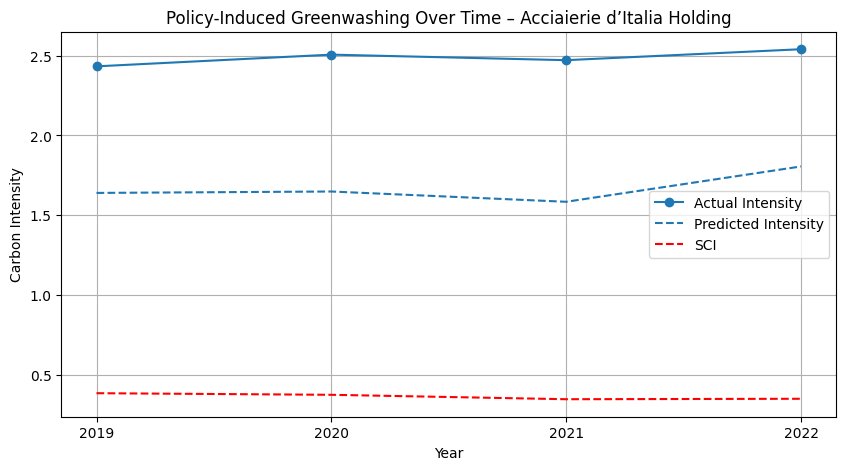

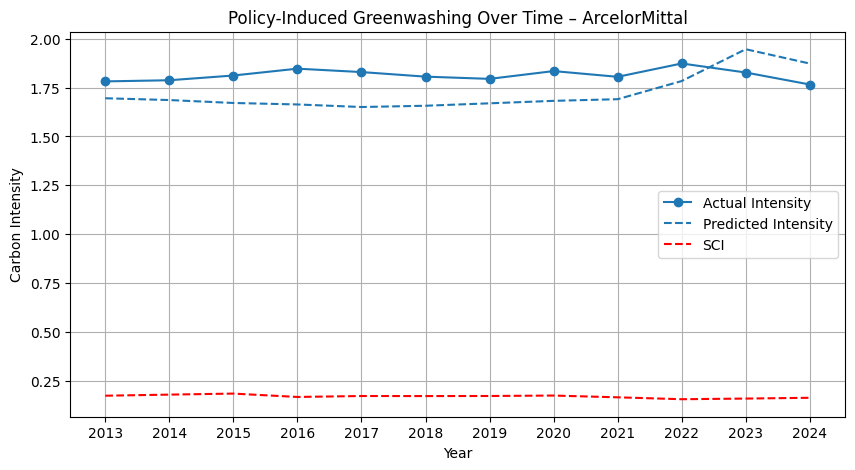

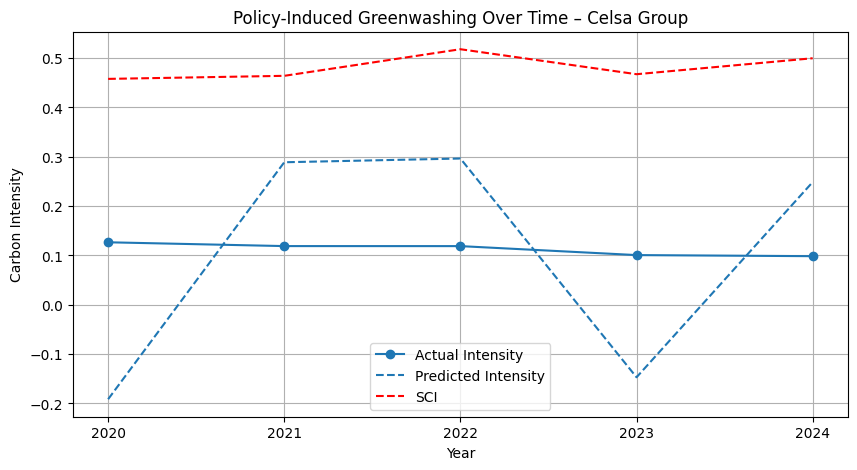

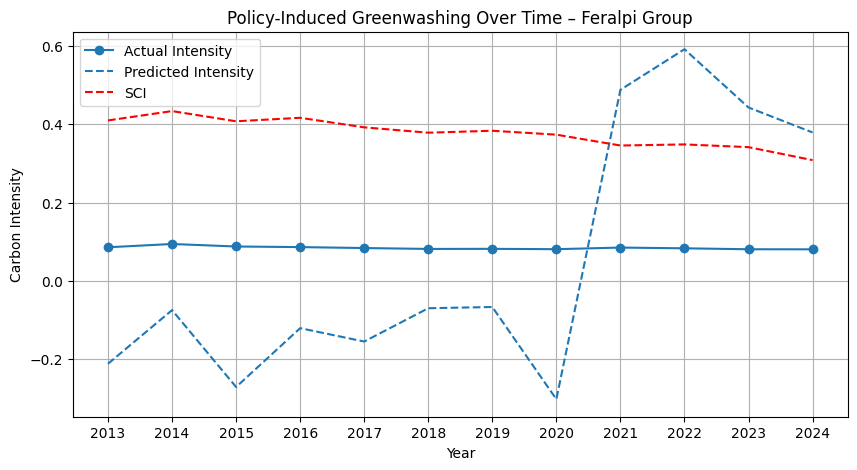

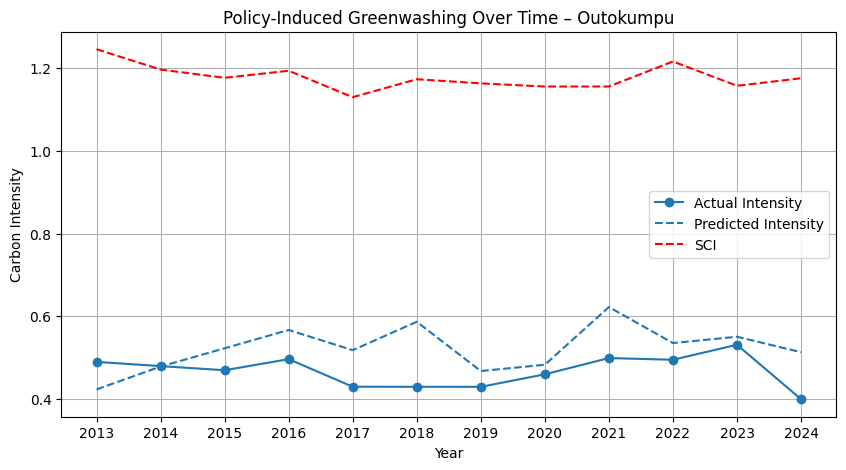

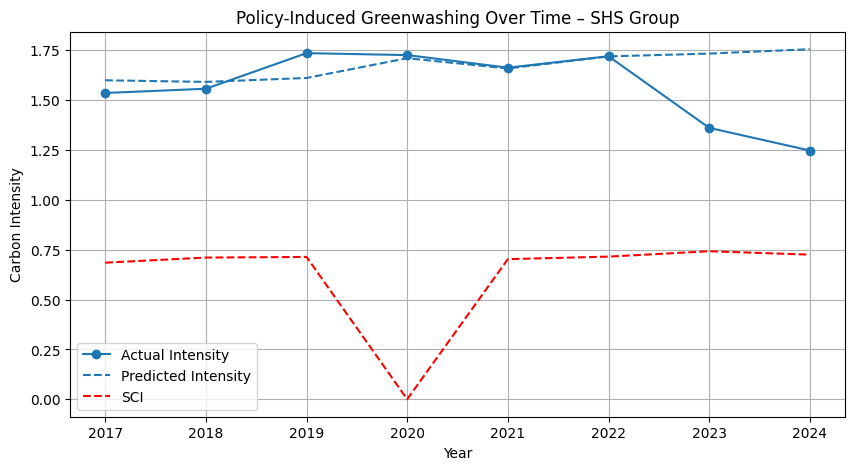

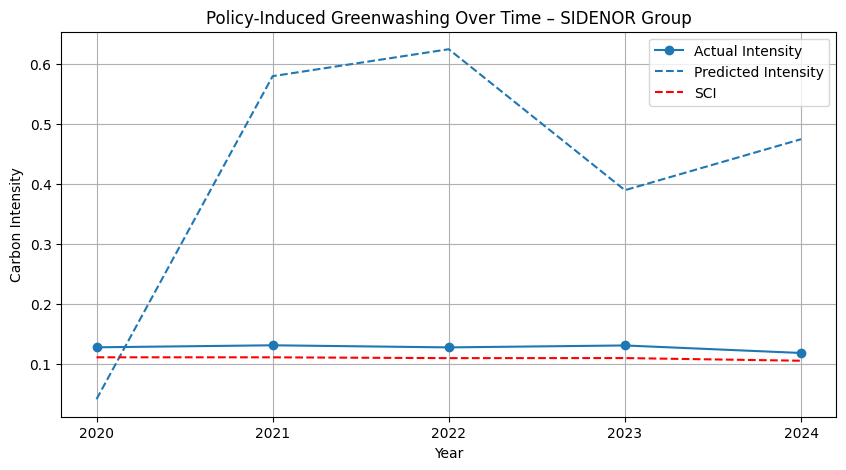

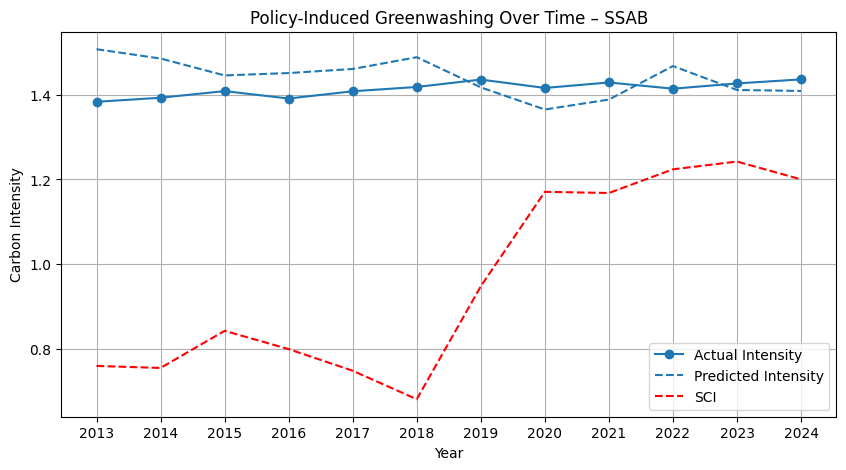

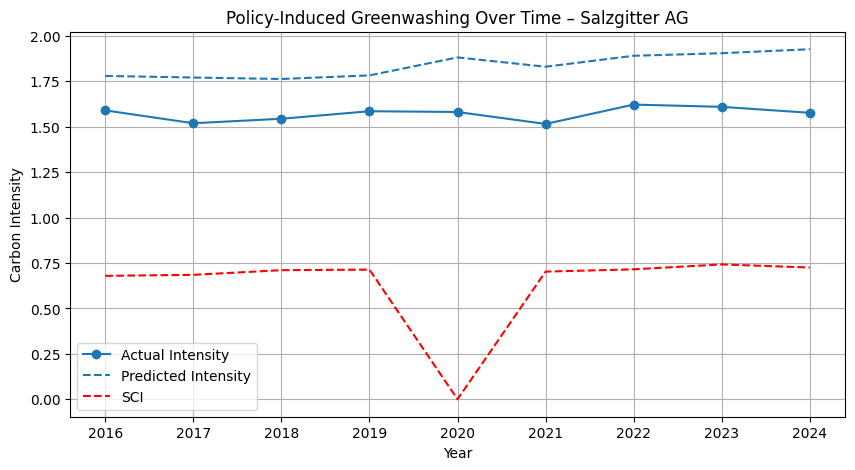

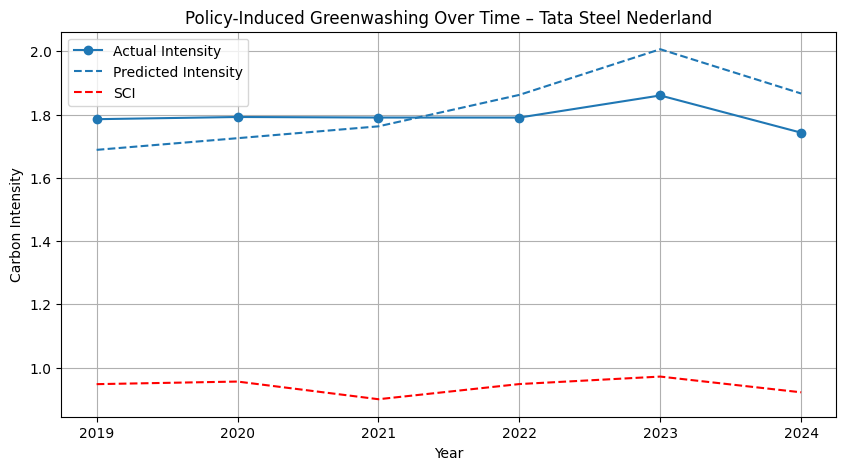

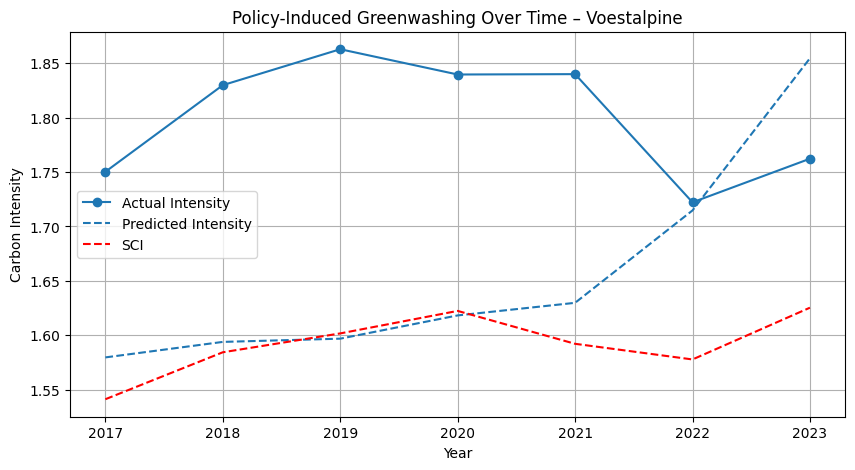

In [ ]:
color_ci = 'C0'  # Carbon intensity
color_pr = 'C1'  # Production
color_sc = 'C2'  # Scope 1 emissions

# 1. Make sure you have the prediction column in df_panel
df_panel['pred_ci_tech'] = modB_ci.fitted_values

# 2. Go to long form with firm + year as columns
panel_long = df_panel.reset_index()

# 3. Compute annual averages per firm
agg = (
    panel_long
    .groupby(['company', 'year'])[['carbon_intensity', 'pred_ci_tech', 'SCI']]
    .mean()
    .reset_index()
)

firms = agg['company'].unique()

# 4. Loop over firms and plot one graph per firm
for firm in firms:
    firm_data = agg[agg['company'] == firm]

    fig, ax = plt.subplots(figsize=(10, 5))

    ax.plot(
        firm_data['year'],
        firm_data['carbon_intensity'],
        marker='o',
        color=color_ci,
        label="Actual Intensity"
    )
    ax.plot(
        firm_data['year'],
        firm_data['pred_ci_tech'],
        linestyle='--',
        color=color_ci,
        label="Predicted Intensity"
    )
    ax.plot(
        firm_data['year'],
        firm_data['SCI'],
        linestyle='--',
        color='red',
        label="SCI"
    )

    ax.set_title(f"Policy-Induced Greenwashing Over Time – {firm}")
    ax.set_ylabel("Carbon Intensity")
    ax.set_xlabel("Year")
    plt.xticks(firm_data['year'].unique())  # force clean labels
    ax.grid(True)
    ax.legend()

    plt.show()

/var/folders/17/__fl3w453559xgr4wcwm1kvc0000gn/T/ipykernel_20919/3170190237.py:84: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter([], [], s=350, c=color, label=tech)
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values



✨ Checking firms for valid CI…

All firms in dataset:
                    company                country
              ArcelorMittal             Luxembourg
       ArcelorMittal Europe Europe (Multi-country)
                Celsa Group                  Spain
                  Outokumpu                Finland
                       SSAB                 Sweden
              Salzgitter AG                Germany
       Tata Steel Nederland            Netherlands
                Voestalpine                Austria
               Dillinger DE                Germany
              Tata Steel UK                     UK
                Acerinox EU                  Spain
Acciaierie d’Italia Holding                  Italy
               Dillinger FR                 France
              SIDENOR Group        Bulgaria-Greece
              Feralpi Group                  Italy
               Nippon Steel                  Japan
                   Baosteel                  China
                  SHS Group

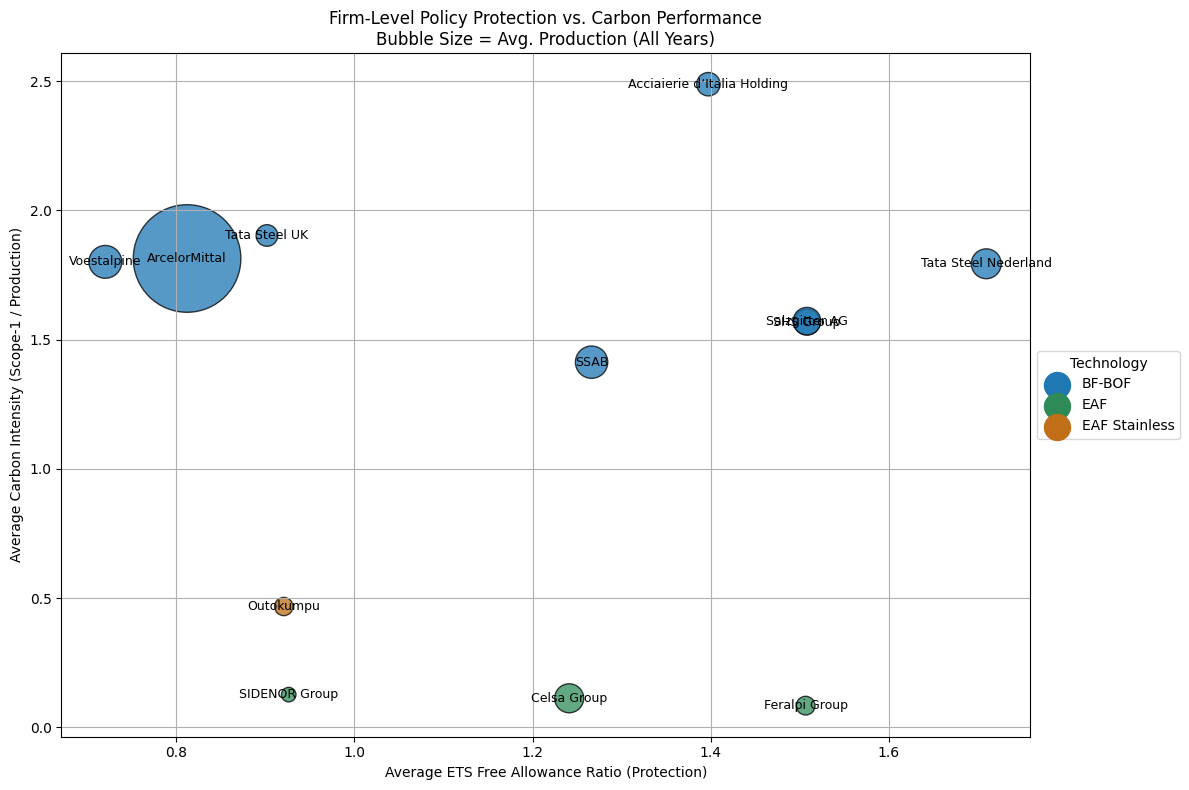

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Reset index to access columns easily
panel_long = df_firms.reset_index()

print("\n✨ Checking firms for valid CI…\n")

# All firms (for reporting)
firms_before = panel_long[['company', 'country']].drop_duplicates()
print("All firms in dataset:")
print(firms_before.to_string(index=False))

# Keep only firms with valid CI
valid_mask = panel_long['carbon_intensity'].notna() & (panel_long['carbon_intensity'] > 0)
panel_valid = panel_long[valid_mask]

# Firms excluded from analysis
firms_after = panel_valid[['company', 'country']].drop_duplicates()
dropped = firms_before.merge(firms_after, how='outer', indicator=True)
dropped = dropped[dropped['_merge'] == 'left_only'].drop(columns=['_merge'])

if not dropped.empty:
    print("\n❌ Firms DROPPED (Missing/zero Scope-1 CI):")
    print(dropped.to_string(index=False))
else:
    print("\n👍 No firms dropped")

print("\n✔ Firms included in firm-avg bubble plot:")
print(firms_after.to_string(index=False))

# Calculate firm averages across all available years
df_avg = (
    panel_valid
    .groupby(['company', 'technology', 'country'])
    .agg({
        'carbon_intensity': 'mean',
        'SCI': 'mean',
        'production': 'mean',
        'ETS_free_ratio': 'mean',
    })
    .reset_index()
)

# Bubble sizes: production scaling
size_scale = 6000  # <-- adjust if you want bigger or smaller bubbles
sizes = (df_avg['production'] / df_avg['production'].max()) * size_scale

# Dynamic color mapping by technology
unique_tech = df_avg['technology'].unique()
tech_colors = {'EAF': '#2E8B57', 'BF/BOF': '#C62828', 'EAF Stainless': "#C06E17"}
color_map = {tech: tech_colors.get(tech, plt.cm.tab10(i)) for i, tech in enumerate(unique_tech)}

fig, ax = plt.subplots(figsize=(12, 8))

# Bubble scatter
ax.scatter(
    df_avg['ETS_free_ratio'],  # X-axis
    df_avg['carbon_intensity'],  # Y-axis
    s=sizes,
    alpha=0.75,
    edgecolor='black',
    c=df_avg['technology'].map(color_map)
)

# Bubble labels (firm names)
for _, row in df_avg.iterrows():
    ax.text(
        row['ETS_free_ratio'],
        row['carbon_intensity'],
        row['company'],
        fontsize=9,
        ha='center',
        va='center'
    )

ax.set_xlabel("Average ETS Free Allowance Ratio (Protection)")
ax.set_ylabel("Average Carbon Intensity (Scope-1 / Production)")
ax.set_title("Firm-Level Policy Protection vs. Carbon Performance\nBubble Size = Avg. Production (All Years)")
ax.grid(True)

# Technology legend positioned middle-left outside plot
for tech, color in color_map.items():
    ax.scatter([], [], s=350, c=color, label=tech)
ax.legend(title="Technology", loc='center left', bbox_to_anchor=(1, 0.5))

plt.tight_layout()
plt.show()









In [52]:
df_panel.groupby('technology')['carbon_intensity'].mean().sort_values()

technology
EAF              0.100413
EAF Stainless    0.467754
BF-BOF           1.673277
Name: carbon_intensity, dtype: float64

## Why these specific % rates? (on the script below - 6. DEFINE THREE POLICY SCENARIOS ON FUTURE PANEL)

| Scenario                | ETS_free_ratio annual decline | SCI improvement | Policy rationale                                        |
| ----------------------- | ----------------------------- | --------------- | ------------------------------------------------------- |
| **BAU**                 | **1%/yr**                     | **1%/yr**       | Continuation of current slow decarbonization trend      |
| **Policy Tightening**   | **8%/yr**                     | **3%/yr**       | EU ETS Phase IV accelerated phase-out + tech diffusion  |
| **Hydrogen Transition** | **10%/yr**                    | **6%/yr**       | Fit-for-55 + Hydrogen strategy + large CAPEX deployment |



=== Acciaierie d’Italia Holding ===
Train years: [2019, 2020]
Test  years: [2021, 2022]

=== Celsa Group ===
Train years: [2020, 2021, 2022]
Test  years: [2023, 2024]

=== Feralpi Group ===
Train years: [2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020]
Test  years: [2021, 2022, 2023, 2024]

=== Outokumpu ===
Train years: [2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020]
Test  years: [2021, 2022, 2023, 2024]

=== SHS Group ===
Train years: [2017, 2018, 2019, 2020, 2021]
Test  years: [2022, 2023, 2024]

=== SIDENOR Group ===
Train years: [2020, 2021, 2022]
Test  years: [2023, 2024]

=== SSAB ===
Train years: [2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020]
Test  years: [2021, 2022, 2023, 2024]

=== Salzgitter AG ===
Train years: [2016, 2017, 2018, 2019, 2020, 2021]
Test  years: [2022, 2023, 2024]

=== Tata Steel Nederland ===
Train years: [2019, 2020, 2021, 2022]
Test  years: [2023, 2024]

=== Voestalpine ===
Train years: [2017, 2018, 2019, 2020]
Test  years: [2021, 2022, 2023]

Final sha

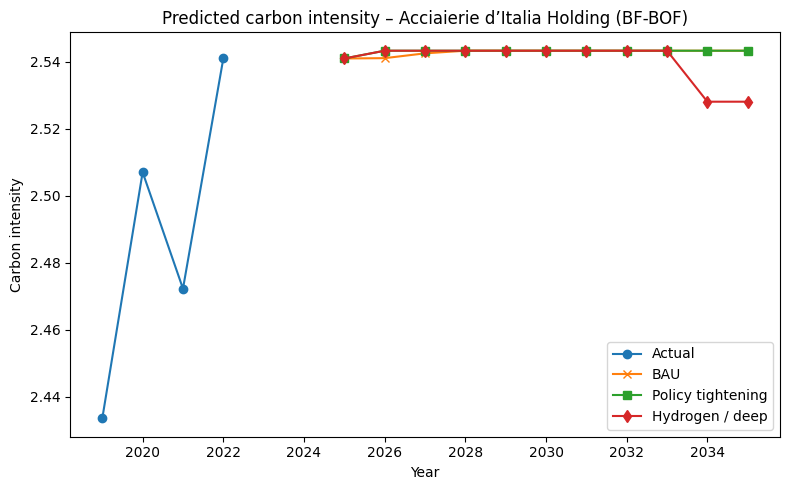

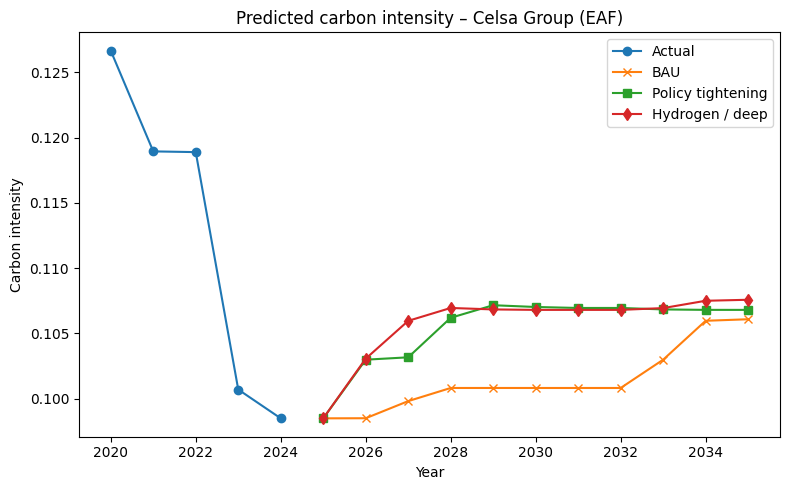

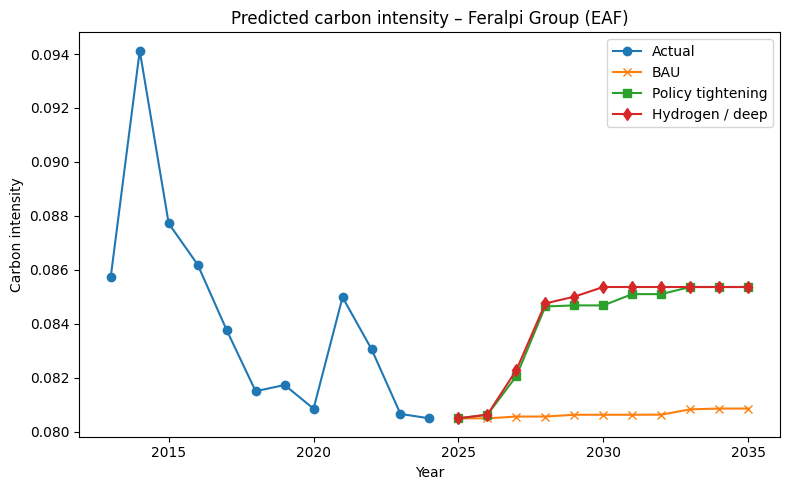

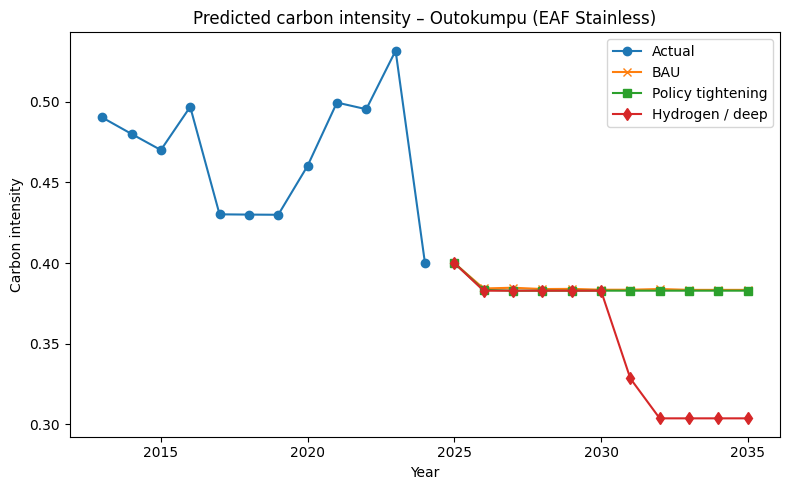

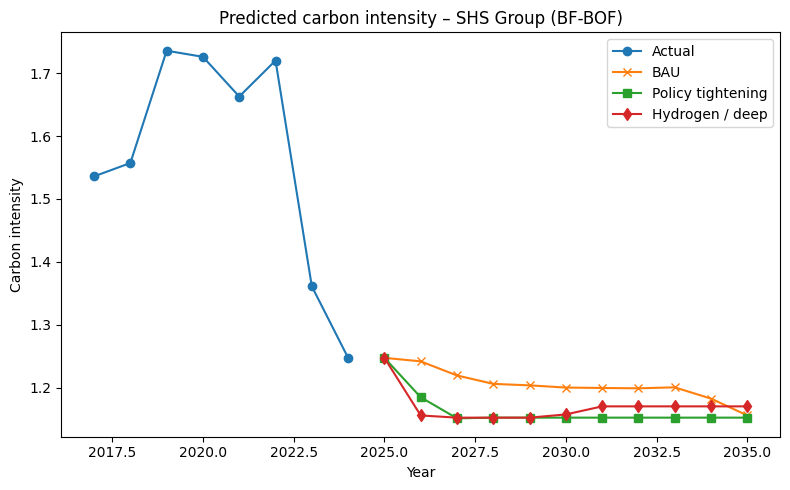

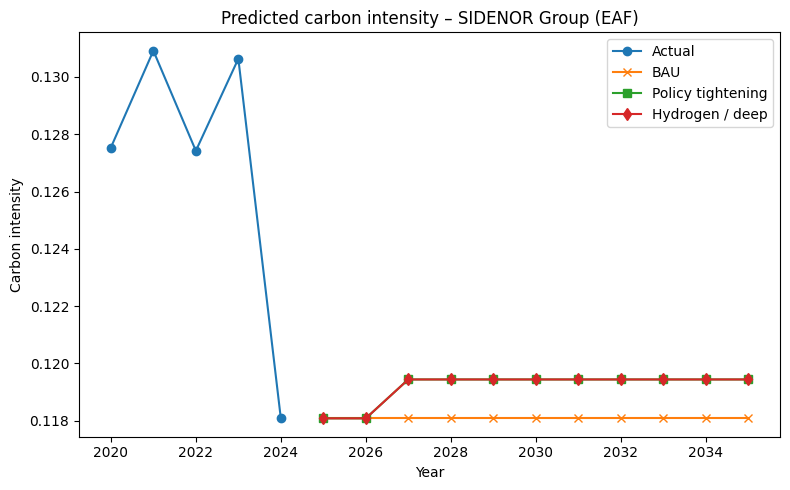

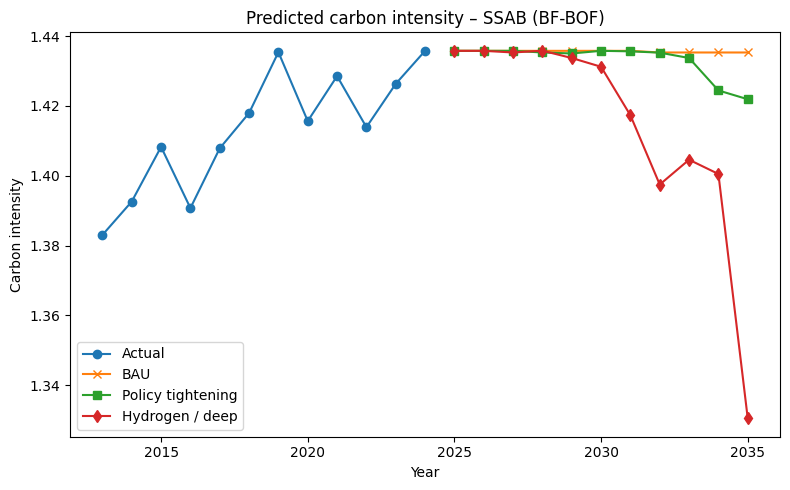

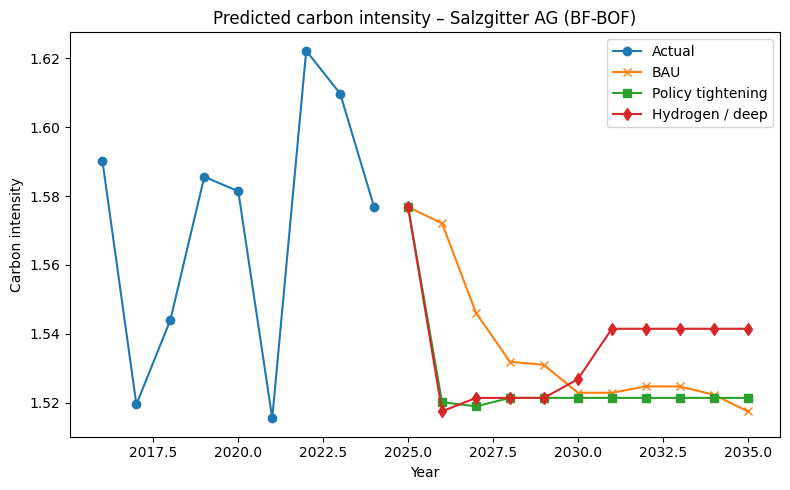

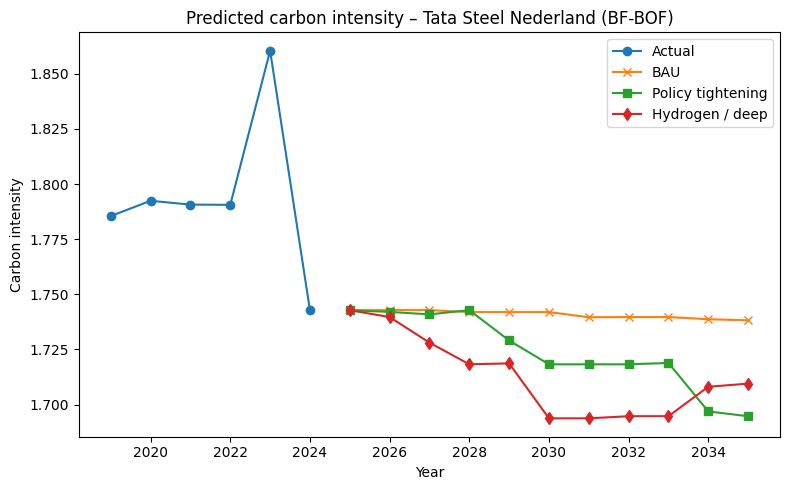

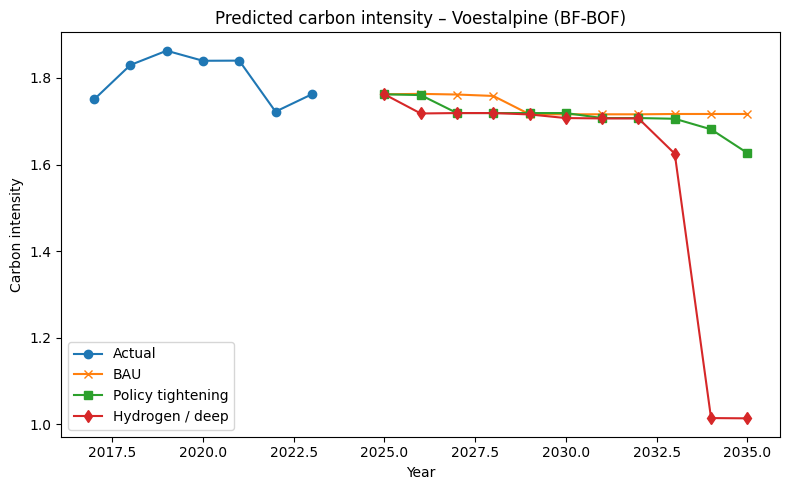

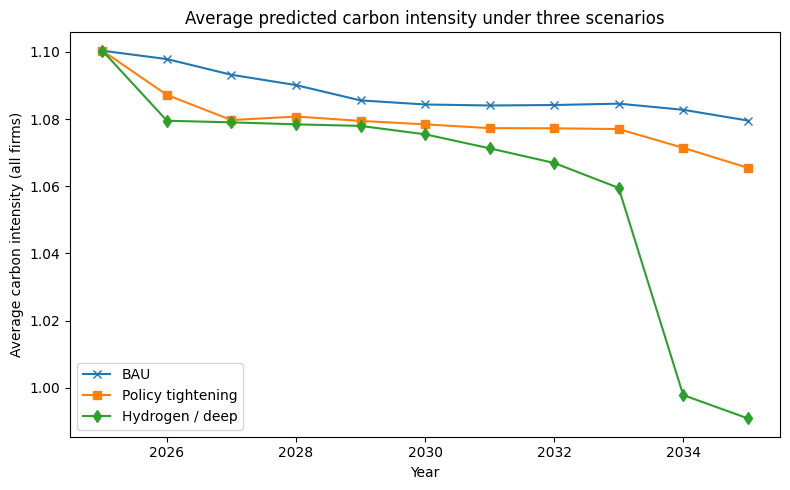

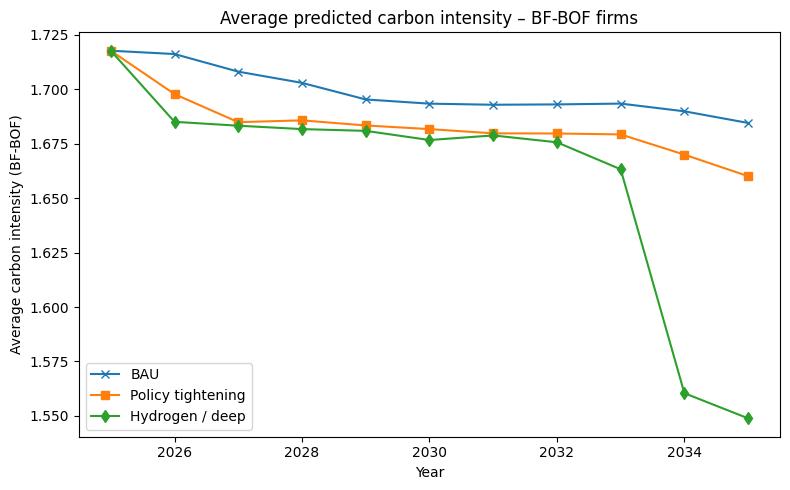

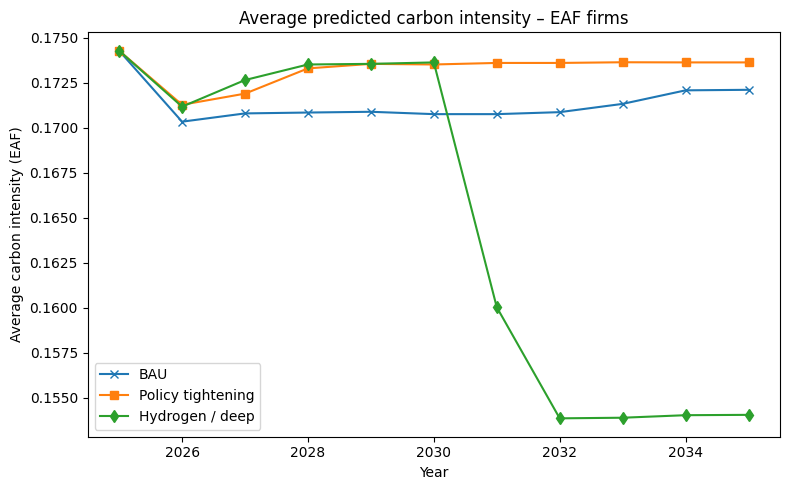

In [64]:
# ===============================================
# 0. IMPORTS
# ===============================================

import numpy as np
import pandas as pd

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error

import matplotlib.pyplot as plt


# ===============================================
# 1. STARTING POINT: df_panel
# ===============================================
# Assumptions about df_panel:
# - MultiIndex: ['company', 'year']
# - Columns include at least:
#   'carbon_intensity', 'ETS_free_ratio', 'electricity_price',
#   'SCI', 'client_pressure_score', 'technology'
# - ArcelorMittal already removed
# - Years go up to 2024 (or similar)

# If BFBOF and ETSxBF are not yet created, do it here:
df_panel = df_panel.copy()




# ===============================================
# 2. PREPARE DATA FOR MACHINE LEARNING
# ===============================================


# 1. Bring index to columns
df_ml = df_panel.reset_index().copy()

# 2. Features and target
feature_cols_base = [
    'ETSxBF',
    'electricity_price',
    'SCI',
    'ETS_free_ratio',
    'client_pressure_score'
]
target_col = 'carbon_intensity'

# 3. Drop missing rows (include technology too if you need it for all obs)
df_ml = df_ml.dropna(
    subset=feature_cols_base + [target_col, 'company', 'year', 'technology']
)

# 4. Firm dummies (X part) – keep prefix consistent with scenarios
firm_dummies = pd.get_dummies(df_ml['company'], prefix='', prefix_sep='')
dummy_cols = firm_dummies.columns  # save for future use

# 5. Technology dummies
tech_dummies = pd.get_dummies(df_ml['technology'], prefix='tech')
tech_dummy_cols = tech_dummies.columns  # save for future use

# 6. Final X matrix
X = pd.concat(
    [df_ml[feature_cols_base], tech_dummies, firm_dummies],
    axis=1
)

# 7. Target as Series (y part)
y_series = df_ml[target_col].copy()

dummy_cols = firm_dummies.columns



# ===============================================
# 3. TRAIN–TEST SPLIT (BY YEAR)
# ===============================================
# We split by time, not randomly, to mimic "train on past, test on recent years".

from sklearn.model_selection import train_test_split
import numpy as np

X_train_list = []
X_test_list = []
y_train_list = []
y_test_list = []

for firm, df_firm in df_ml.groupby("company"):
    # sort this firm's rows by year
    df_sorted = df_firm.sort_values("year")
    idx = df_sorted.index              # indices into df_ml (and X, y_series)
    years = df_sorted['year'].tolist() # list of years for this firm

    if len(idx) <= 3:
        # few observations: use all but last for train, last for test
        train_idx = idx[:-1]
        test_idx  = idx[-1:]
        train_years = years[:-1]
        test_years  = years[-1:]
    else:
        # ~70% earliest years for train, rest for test
        split_pos = int(0.7 * len(idx))
        train_idx = idx[:split_pos]
        test_idx  = idx[split_pos:]
        train_years = years[:split_pos]
        test_years  = years[split_pos:]

    # print which years were train/test for this firm
    print(f"\n=== {firm} ===")
    print("Train years:", train_years)
    print("Test  years:", test_years)

    # build train/test sets using the global X and y_series
    X_train_list.append(X.loc[train_idx])
    y_train_list.append(y_series.loc[train_idx])
    X_test_list.append(X.loc[test_idx])
    y_test_list.append(y_series.loc[test_idx])

# concatenate across firms
X_train = pd.concat(X_train_list)
y_train = pd.concat(y_train_list)
X_test  = pd.concat(X_test_list)
y_test  = pd.concat(y_test_list)

print("\nFinal shapes:")
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)








# ===============================================
# 4. TRAIN RANDOM FOREST REGRESSOR
# ===============================================

rf = RandomForestRegressor(
    n_estimators=500,      # number of trees
    max_depth=None,        # let trees grow until pure/stop
    random_state=42,
    n_jobs=-1              # use all cores
)

rf.fit(X_train, y_train)

# Evaluate on test set
y_pred_test = rf.predict(X_test)

print("\n=== Random Forest Performance on Test Years ===")
print("Test R²: ", r2_score(y_test, y_pred_test))
print("Test MAE:", mean_absolute_error(y_test, y_pred_test))
imp = pd.Series(rf.feature_importances_, index=X_train.columns).sort_values(ascending=False)
print(imp.head(20))


# ===============================================
# 5. BUILD FUTURE BASE PANEL (2025–2035)
# ===============================================
# We start from each firm's last observed year and extend forward.

last_year = max_year        # e.g. 2024
future_years = list(range(last_year + 1, 2035 + 1))   # 2025–2035

# Take last observed row per firm (represents 2024 levels)
last_rows = (
    df_ml
      .sort_values('year')
      .groupby('company')
      .last()
)

rows = []
for firm, row in last_rows.iterrows():
    for year in future_years:
        r = row.copy()
        r['company'] = firm
        r['year'] = year
        rows.append(r)

future_base = pd.DataFrame(rows)

# IMPORTANT: We only keep columns we need and ensure BFBOF is present
# (it already exists in df_panel, and was carried into df_ml)
future_base = pd.DataFrame(rows)

# IMPORTANT: We keep technology too, so we can build tech dummies in scenarios
future_base = future_base[
    ['company', 'year', 'technology'] +
    feature_cols_base +     # ['ETSxBF','electricity_price','SCI','ETS_free_ratio','client_pressure_score']
    ['BFBOF']
].copy()



# ===============================================
# 6. DEFINE THREE POLICY SCENARIOS ON FUTURE PANEL
# ===============================================
# Logic:
# - For each scenario, we modify ETS_free_ratio and SCI over time.
# - Recompute ETSxBF = ETS_free_ratio * BFBOF.
# - Other covariates (electricity_price, client_pressure_score) kept constant.

# Compute how far in the future each row is (0 in first future year, etc.)
years_ahead = future_base['year'] - (last_year + 1)

# 6.1 Business As Usual (BAU): very slow decarbonization
bau = future_base.copy()
bau['ETS_free_ratio'] = bau['ETS_free_ratio'] * (0.99 ** years_ahead)   # ~1% decline/year
bau['SCI']            = bau['SCI']            * (0.99 ** years_ahead)   # slight CI improvement
bau['ETSxBF']         = bau['ETS_free_ratio'] * bau['BFBOF']

# 6.2 Policy Tightening: strong phase-out of free allowances
tight = future_base.copy()
tight['ETS_free_ratio'] = tight['ETS_free_ratio'] * (0.92 ** years_ahead)  # ~8% decline/year
tight['SCI']            = tight['SCI']            * (0.97 ** years_ahead)  # faster CI reduction
tight['ETSxBF']         = tight['ETS_free_ratio'] * tight['BFBOF']

# 6.3 Hydrogen / Deep Transition: very strong decarbonization
h2 = future_base.copy()
h2['ETS_free_ratio'] = h2['ETS_free_ratio'] * (0.90 ** years_ahead)  # ~10% decline/year
h2['SCI']            = h2['SCI']            * (0.94 ** years_ahead)  # strong CI improvement
h2['ETSxBF']         = h2['ETS_free_ratio'] * h2['BFBOF']


# ===============================================
# 7. BUILD FEATURE MATRICES FOR EACH SCENARIO
# ===============================================
# We need the same structure as X_train:
#   [feature_cols_base] + firm dummies with the SAME columns (dummy_cols)

def build_X_for_scenario(df_scen):
    """
    df_scen: DataFrame with columns:
        'company', 'year', 'technology', feature_cols_base, 'BFBOF'
    Returns:
        scen_flat: df with company, year, technology, features
        X_scen:    feature matrix with EXACTLY the same columns (name + order)
                  as X_train used in rf.fit()
    """
    scen_flat = df_scen.copy()

    # Base features in same order as training
    feat = scen_flat[feature_cols_base].copy()

    # Firm dummies, same prefix and columns as training
    d_firm = pd.get_dummies(scen_flat['company'], prefix='', prefix_sep='')
    d_firm = d_firm.reindex(columns=dummy_cols, fill_value=0)

    # Technology dummies, same columns as training
    d_tech = pd.get_dummies(scen_flat['technology'], prefix='tech')
    d_tech = d_tech.reindex(columns=tech_dummy_cols, fill_value=0)

    # Combine in SAME logical order as training: features + tech + firm
    X_raw = pd.concat([feat, d_tech, d_firm], axis=1)

    # FINAL STEP: enforce columns to match X_train exactly (names + order)
    X_scen = X_raw.reindex(columns=X_train.columns, fill_value=0)

    return scen_flat, X_scen


bau_scen,   X_bau   = build_X_for_scenario(bau)
tight_scen, X_tight = build_X_for_scenario(tight)
h2_scen,    X_h2    = build_X_for_scenario(h2)


# ===============================================
# 8. PREDICT CARBON INTENSITY FOR EACH SCENARIO
# ===============================================

bau_scen['CI_pred_BAU']     = rf.predict(X_bau)
tight_scen['CI_pred_Tight'] = rf.predict(X_tight)
h2_scen['CI_pred_H2']       = rf.predict(X_h2)

# Keep only relevant columns
bau_scen   = bau_scen[['company', 'year', 'CI_pred_BAU']]
tight_scen = tight_scen[['company', 'year', 'CI_pred_Tight']]
h2_scen    = h2_scen[['company', 'year', 'CI_pred_H2']]

# Merge into a single future predictions table
future_preds = (
    bau_scen
      .merge(tight_scen, on=['company','year'])
      .merge(h2_scen,    on=['company','year'])
      .set_index(['company','year'])
      .sort_index()
)

print("\n=== Example of future predictions (head) ===")
print(future_preds.head())


first_future_year = future_years[0]  # this is 2025

rows_adj = []

# loop firm by firm
for firm, df_firm in future_preds.reset_index().groupby('company'):
    df_firm = df_firm.sort_values('year').copy()

    # last actual CI for this firm (e.g. 2024)
    hist_firm = (
        df_ml[df_ml['company'] == firm]
        .sort_values('year')
    )
    ci_last_actual = hist_firm['carbon_intensity'].iloc[-1]

    # BAU prediction in first future year (e.g. 2025)
    ci_bau_first = df_firm.loc[
        df_firm['year'] == first_future_year, 'CI_pred_BAU'
    ].iloc[0]

    # difference between model and reality at the “join” point
    gap = ci_bau_first - ci_last_actual

    # shift ALL future predictions down by this gap
    df_firm['CI_BAU_adj']   = df_firm['CI_pred_BAU']   - gap
    df_firm['CI_Tight_adj'] = df_firm['CI_pred_Tight'] - gap
    df_firm['CI_H2_adj']    = df_firm['CI_pred_H2']    - gap

    rows_adj.append(df_firm[['company','year',
                             'CI_BAU_adj','CI_Tight_adj','CI_H2_adj']])

future_preds_adj = (
    pd.concat(rows_adj)
      .set_index(['company','year'])
      .sort_index()
)



# ===============================================
# 9. OPTIONAL: PLOT FOR ALL THE FIRMS
# ===============================================

import os
import matplotlib.pyplot as plt

import os
import matplotlib.pyplot as plt

#out_dir = "firm_plots"
#os.makedirs(out_dir, exist_ok=True)

firms = sorted(df_ml['company'].unique())

for firm_name in firms:

    # --- historical data ---
    hist = (
        df_ml[df_ml['company'] == firm_name]
        .groupby('year', as_index=False)['carbon_intensity']
        .mean()
        .sort_values('year')
    )

    # --- get most recent technology entry ---
    tech_info = (
        df_ml[df_ml['company'] == firm_name]
        .sort_values('year')['technology']
        .iloc[-1]   # technology in latest observed year
    )

    # --- future adjusted predictions ---
    fut = (
        future_preds_adj
          .reset_index()
          .query("company == @firm_name")
          .sort_values('year')
    )

    if fut.empty or hist.empty:
        continue

    # --- plot ---
    plt.figure(figsize=(8,5))
    plt.plot(hist['year'], hist['carbon_intensity'], label='Actual', marker='o')
    plt.plot(fut['year'], fut['CI_BAU_adj'],   label='BAU',               marker='x')
    plt.plot(fut['year'], fut['CI_Tight_adj'], label='Policy tightening', marker='s')
    plt.plot(fut['year'], fut['CI_H2_adj'],    label='Hydrogen / deep',   marker='d')

    plt.xlabel("Year")
    plt.ylabel("Carbon intensity")
    plt.title(f"Predicted carbon intensity – {firm_name} ({tech_info})")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # save
    #safe_name = firm_name.replace("/", "_").replace("\\", "_")
    #plt.savefig(os.path.join(out_dir, f"CI_{safe_name}.png"), dpi=150)
    plt.close()





# ===============================================
# 10. OPTIONAL: PLOT EU AVERAGE CI PER SCENARIO
# ===============================================

# Average across all firms by year
avg_future = (
    future_preds_adj
      .reset_index()
      .groupby('year')[['CI_BAU_adj','CI_Tight_adj','CI_H2_adj']]
      .mean()
      .reset_index()
)

plt.figure(figsize=(8,5))
plt.plot(avg_future['year'], avg_future['CI_BAU_adj'],   label='BAU',               marker='x')
plt.plot(avg_future['year'], avg_future['CI_Tight_adj'], label='Policy tightening', marker='s')
plt.plot(avg_future['year'], avg_future['CI_H2_adj'],    label='Hydrogen / deep',   marker='d')

plt.xlabel("Year")
plt.ylabel("Average carbon intensity (all firms)")
plt.title("Average predicted carbon intensity under three scenarios")
plt.legend()
plt.tight_layout()
plt.show()


# ===============================================
# 11. Average CI per scenario, split by technology
# ===============================================

# 1. Classify firms by their latest technology
firm_latest_tech = (
    df_ml.sort_values('year')
         .groupby('company')['technology']
         .last()
)

# BF-BOF firms
bf_firms = firm_latest_tech[firm_latest_tech.str.contains("BF", case=False)].index

# EAF firms (includes EAF Stainless etc.)
eaf_firms = firm_latest_tech[firm_latest_tech.str.contains("EAF", case=False)].index


# ---------- BF-BOF AVERAGE ----------
bf_future = (
    future_preds_adj
      .reset_index()
      .query("company in @bf_firms")
      .groupby('year')[['CI_BAU_adj','CI_Tight_adj','CI_H2_adj']]
      .mean()
      .reset_index()
)

plt.figure(figsize=(8,5))
plt.plot(bf_future['year'], bf_future['CI_BAU_adj'],   label='BAU',               marker='x')
plt.plot(bf_future['year'], bf_future['CI_Tight_adj'], label='Policy tightening', marker='s')
plt.plot(bf_future['year'], bf_future['CI_H2_adj'],    label='Hydrogen / deep',   marker='d')
plt.xlabel("Year")
plt.ylabel("Average carbon intensity (BF-BOF)")
plt.title("Average predicted carbon intensity – BF-BOF firms")
plt.legend()
plt.tight_layout()
plt.show()


# ---------- EAF AVERAGE ----------
eaf_future = (
    future_preds_adj
      .reset_index()
      .query("company in @eaf_firms")
      .groupby('year')[['CI_BAU_adj','CI_Tight_adj','CI_H2_adj']]
      .mean()
      .reset_index()
)

plt.figure(figsize=(8,5))
plt.plot(eaf_future['year'], eaf_future['CI_BAU_adj'],   label='BAU',               marker='x')
plt.plot(eaf_future['year'], eaf_future['CI_Tight_adj'], label='Policy tightening', marker='s')
plt.plot(eaf_future['year'], eaf_future['CI_H2_adj'],    label='Hydrogen / deep',   marker='d')
plt.xlabel("Year")
plt.ylabel("Average carbon intensity (EAF)")
plt.title("Average predicted carbon intensity – EAF firms")
plt.legend()
plt.tight_layout()
plt.show()








## 🌍 Real-world correspondence

### The Hydrogen scenario matches:


| Policy / Industry Plan              | Target timing |
| ----------------------------------- | ------------- |
| EU Hydrogen Backbone infrastructure | 2030–2032     |
| First commercial green-steel plants | 2029–2032     |
| SSAB fossil-free steel              | by 2030       |
| Salzgitter SALCOS transformation    | 2029–2033     |
| CBAM full implementation            | 2032          |
| Free ETS allowances phase-out       | 2034–2035     |



In [30]:
!pip install pdfplumber
import pdfplumber
import glob
import os

paths = glob.glob("data/reports/TataStee*/*.pdf")
if not paths:
    print("No PDF files found!")
else:
    for path in paths:
        print("\n=== File:", os.path.basename(path), "===")
        with pdfplumber.open(path) as pdf:
            print("Pages:", len(pdf.pages))
            first_page = pdf.pages[0]
            first_page_text = first_page.extract_text() or ""
            print(first_page_text[:1000])


=== File: 006_2024_annual_report.pdf ===
Pages: 93
Annual Report and Accounts 2024–2025

=== File: 006_2021_sustainability_report.pdf ===
Pages: 48
Tata Steel Nederland
SUSTAINABILITY REPORT
2021/2022
Together we make the difference

=== File: 006_2023_annual_report.pdf ===
Pages: 95
Annual Report & Accounts 2023-2024

=== File: 006_2022_sustainability_report.pdf ===


Cannot set gray stroke color because /'P0' is an invalid float value
Cannot set gray stroke color because /'P1' is an invalid float value


Pages: 57
Sustainability Report 2022/2023

=== File: 010_2022_sustainability_report.pdf ===
Pages: 87
Business Responsibility and Sustainability Report
BUSINESS RESPONSIBILITY AND SUSTAINABILITY REPORT
Financial Year 2022-23
Index
SECTION A: GENERAL DISCLOSURES 139
SECTION B: MANAGEMENT AND PROCESS DISCLOSURES 154
SECTION C: PRINCIPLE-WISE PERFORMANCE DISCLOSURES 160
Principle 1: Businesses should conduct and govern themselves with integrity, and in a manner 160
that is ethical, transparent and accountable
Principle 2: Businesses should provide goods and services in a manner that is sustainable and safe 163
Principle 3: Businesses should respect and promote the well-being of all employees, 169
including those in their value chains
Principle 4: Businesses should respect the interests of and be responsive to all its stakeholders 184
Principle 5: Businesses should respect and promote human rights 190
Principle 6: Businesses should respect and make efforts to protect and restore the enviro

In [31]:
import os
import re

import os
import re

# Fill this mapping based on your actual IDs per region
ID_TO_COUNTRY = {
    "006": "UK",  # example
    "010": "NL",
    # "008": "UK",
    # ...
}

def extract_country_year_from_path(path: str):
    """
    Parse country and year from a path like:
      - '/data/TataSteelUK/006_2024_annual_report.pdf'
      - '/data/TataSteelNL/010_2023_sustainability.pdf'

    Logic:
      1) Determine country from folder names (TataSteelUK, TataSteelNL, 'UK', 'NL', etc.)
      2) If still UNKNOWN, try mapping the 3-digit file ID prefix (e.g. '006') to a country
      3) Extract a 4-digit year (2000–2039) from the filename
    """
    # --- 1. Country from folder names ---
    country = "UNKNOWN"
    parts = [p.lower() for p in os.path.normpath(path).split(os.sep) if p]

    for part in parts:
        # TataSteelUK / TataSteel-UK / TataSteel_UK
        if "tatasteeluk" in part or re.search(r"\buk\b", part):
            country = "UK"
            break
        # TataSteelNL / TataSteel-NL / TataSteel_NL
        if "tatasteelnederland" in part or re.search(r"\bnl\b", part):
            country = "NL"
            break
        # Add more countries if needed, e.g.:
        # if "tatasteelde" in part or "germany" in part or "deutschland" in part:
        #     country = "DE"
        #     break

    fname = os.path.basename(path)

    # --- 2. Country from 3-digit ID prefix in filename ---
    # e.g. '006_2024_annual_report.pdf' -> '006'
    m_id = re.match(r"(\d{3})_", fname)
    if country == "UNKNOWN" and m_id:
        prefix = m_id.group(1)
        country = ID_TO_COUNTRY.get(prefix, "UNKNOWN")

    # --- 3. Year from filename ---
    # Look for a 4-digit year starting with 20 (2000–2039)
    m_year = re.search(r"(20[0-3][0-9])", fname)
    year = int(m_year.group(1)) if m_year else None

    return country, year




In [32]:
import zipfile
import pdfplumber
import os

import os
import pdfplumber

all_docs = []

base_dir = "data/reports"  # or absolute path if you prefer

# find all TataSteel* folders under base_dir
tata_dirs = [
    os.path.join(base_dir, d)
    for d in os.listdir(base_dir)
    if d.startswith("TataSteel") and os.path.isdir(os.path.join(base_dir, d))
]

for root_dir in tata_dirs:
    for dirpath, dirnames, filenames in os.walk(root_dir):
        for fname in filenames:
            if not fname.lower().endswith(".pdf"):
                continue  # skip non-PDFs

            pdf_path = os.path.join(dirpath, fname)

            # use your updated function that handles folders + filename
            country, year = extract_country_year_from_path(pdf_path)

            with pdfplumber.open(pdf_path) as pdf:
                pages_text = []
                for page in pdf.pages:
                    page_text = page.extract_text() or ""
                    pages_text.append(page_text)
                full_text = "\n".join(pages_text)

            all_docs.append({
                "source_path": pdf_path,
                "pdf_name": fname,
                "country": country,
                "year": year,
                "text": full_text,
            })

# quick sanity check
len(all_docs), all_docs[0]["source_path"], all_docs[0]["pdf_name"], all_docs[0]["country"], all_docs[0]["year"]



Cannot set gray stroke color because /'P0' is an invalid float value
Cannot set gray stroke color because /'P1' is an invalid float value
Cannot set gray stroke color because /'P2' is an invalid float value
Cannot set gray stroke color because /'P3' is an invalid float value
Cannot set gray stroke color because /'P4' is an invalid float value
Cannot set gray stroke color because /'P0' is an invalid float value
Cannot set gray stroke color because /'P1' is an invalid float value
Cannot set gray stroke color because /'P2' is an invalid float value
Cannot set gray stroke color because /'P3' is an invalid float value
Cannot set gray stroke color because /'P4' is an invalid float value
Cannot set gray stroke color because /'P0' is an invalid float value
Cannot set gray stroke color because /'P1' is an invalid float value
Cannot set gray stroke color because /'P2' is an invalid float value
Cannot set gray stroke color because /'P3' is an invalid float value
Cannot set gray stroke color becau

(8,
 'data/reports/TataSteelNederland/006_2024_annual_report.pdf',
 '006_2024_annual_report.pdf',
 'NL',
 2024)

In [ ]:
df_docs = pd.DataFrame(all_docs)
df_docs[["source_path", "pdf_name", "country", "year"]]


,source_path,pdf_name,country,year
0,data/reports/TataSteelNederland/006_2024_annual_report.pdf,006_2024_annual_report.pdf,NL,2024
1,data/reports/TataSteelNederland/006_2021_sustainability_report.pdf,006_2021_sustainability_report.pdf,NL,2021
2,data/reports/TataSteelNederland/006_2023_annual_report.pdf,006_2023_annual_report.pdf,NL,2023
3,data/reports/TataSteelNederland/006_2022_sustainability_report.pdf,006_2022_sustainability_report.pdf,NL,2022
4,data/reports/TataSteelUK/010_2022_sustainability_report.pdf,010_2022_sustainability_report.pdf,UK,2022
5,data/reports/TataSteelUK/010_2021_sustainability_report.pdf,010_2021_sustainability_report.pdf,UK,2021
6,data/reports/TataSteelUK/010_2024_sustainability_report.pdf,010_2024_sustainability_report.pdf,UK,2024
7,data/reports/TataSteelUK/010_2023_sustainability_report.pdf,010_2023_sustainability_report.pdf,UK,2023


In [ ]:
import re

claim_keywords = [
    # Furnace / route shifts
    "electric arc furnace", "eaf",
    "blast furnace", "bf", "bof", "bf-bof",
    "basic oxygen furnace",
    "direct reduced iron", "dri",
    "hydrogen-based ironmaking", "hydrogen-based steel",
    "scrap-based", "scrap route", "scrap charge",

    # Transition language
    "technology shift", "technology transition",
    "route change", "production route",
    "process change", "process transformation",
    "retrofitting", "retrofitted", "revamping", "revamp",
    "converter replacement", "furnace replacement",
    "blast furnace closure", "blast furnace shutdown",

    # Low-carbon tech options
    "carbon capture", "ccs", "ccus",
    "post-combustion capture", "oxyfuel",
    "electrification of processes", "electrified process",
    "plasma heating", "induction furnace",

    # Hydrogen + DRI context (more concrete than just 'hydrogen')
    "hydrogen dri", "h2 dri", "h2-based dri",
    "shaft furnace", "midrex", "energiron",

    # Feedstock changes
    "high scrap ratio", "increased scrap use",
    "ore-based", "pellet feed", "pelletization",

    # Pilot / demo scale tech
    "pilot plant", "demo plant", "demonstration plant",
    "industrial scale-up", "scaling up", "scale up",
    "commercial scale", "full-scale deployment"
]


def big_words_index(text: str):
    if not text:
        return 0.0
    lower = text.lower()
    # total words
    tokens = re.findall(r"[a-zA-Z]+", lower)
    total_words = len(tokens) if tokens else 1
    
    # keyword hits
    hits = 0
    for kw in claim_keywords:
        hits += lower.count(kw)
    
    return hits / total_words  # frequency per word

df_docs["big_words_index"] = df_docs["text"].apply(big_words_index)
df_docs[["pdf_name", "country", "year", "big_words_index"]]


,pdf_name,country,year,big_words_index
0,006_2024_annual_report.pdf,NL,2024,0.001659
1,006_2021_sustainability_report.pdf,NL,2021,0.002597
2,006_2023_annual_report.pdf,NL,2023,0.001723
3,006_2022_sustainability_report.pdf,NL,2022,0.001800
4,010_2022_sustainability_report.pdf,UK,2022,0.001521
5,010_2021_sustainability_report.pdf,UK,2021,0.001046
6,010_2024_sustainability_report.pdf,UK,2024,0.001406
7,010_2023_sustainability_report.pdf,UK,2023,0.001266


In [ ]:
import numpy as np

embedding_dict = {}

with open("embeddings_output/embedding.txt", "r", encoding="utf-8") as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        # split "token: [v1 v2 ...]"
        if ":" not in line:
            continue
        token, vec_part = line.split(":", 1)
        token = token.strip()
        vec_part = vec_part.strip()
        # remove '[' and ']'
        if vec_part.startswith("[") and vec_part.endswith("]"):
            vec_part = vec_part[1:-1]
        # turn "1.0 2.0 ..." into numpy array
        vec = np.fromstring(vec_part, sep=" ")
        if vec.size > 0:
            embedding_dict[token] = vec

print("Loaded embeddings for", len(embedding_dict), "tokens")



Loaded embeddings for 4904 tokens


In [ ]:
# pick single words that should be in the embedding vocab
claim_seed_words = [
    "eaf", "bf", "bof", "dri", "scrap",
    "hydrogen", "ccus", "capture",
    "transition", "retrofit", "closure",
    "pilot", "demo", "scale-up", "process"
]

def get_vec(token):
    return embedding_dict.get(token.lower())

seed_vecs = [get_vec(w) for w in claim_seed_words if get_vec(w) is not None]

claim_concept = np.mean(seed_vecs, axis=0)  # average vector


In [ ]:
from numpy.linalg import norm

def semantic_claim_index(text: str, sim_threshold=0.4):
    if not text:
        return 0.0
    
    # basic word tokens
    tokens = re.findall(r"[a-zA-Z]+", text.lower())
    if not tokens:
        return 0.0
    
    sims = []
    for t in tokens:
        v = get_vec(t)
        if v is None:
            continue
        denom = norm(v) * norm(claim_concept)
        if denom == 0:
            continue
        sim = float(np.dot(v, claim_concept) / denom)
        sims.append(sim)
    
    if not sims:
        return 0.0
    
    # count how many words are "sufficiently close" to the climate concept
    hits = sum(1 for s in sims if s >= sim_threshold)
    return hits / len(sims)  # fraction of words with embedding that are "claim-like"

df_docs["semantic_claim_index"] = df_docs["text"].apply(semantic_claim_index)

df_docs[["pdf_name", "country", "year", "big_words_index", "semantic_claim_index"]]


,pdf_name,country,year,big_words_index,semantic_claim_index
0,006_2024_annual_report.pdf,NL,2024,0.001659,0.245181
1,006_2021_sustainability_report.pdf,NL,2021,0.002597,0.314823
2,006_2023_annual_report.pdf,NL,2023,0.001723,0.257300
3,006_2022_sustainability_report.pdf,NL,2022,0.001800,0.275212
4,010_2022_sustainability_report.pdf,UK,2022,0.001521,0.196493
5,010_2021_sustainability_report.pdf,UK,2021,0.001046,0.366727
6,010_2024_sustainability_report.pdf,UK,2024,0.001406,0.230314
7,010_2023_sustainability_report.pdf,UK,2023,0.001266,0.216829


| Metric                   | What it measures                   | How it works                                                                           | Typical values                    |
| ------------------------ | ---------------------------------- | -------------------------------------------------------------------------------------- | --------------------------------- |
| **Big Words Index**      | **Explicit** sustainability claims | Counts exact buzzwords in text (`.count()`)                                            | Very small numbers (0.0005–0.004) |
| **Semantic Claim Index** | **Implicit** green narrative tone  | Measures similarity of words to “climate concept” using embeddings (cosine similarity) | Larger values (0.45–0.60)         |


| Company behavior              | Looks like              | Index pattern | Interpretation    |
| ----------------------------- | ----------------------- | ------------- | ----------------- |
| Bold promises but no progress | Marketing hype          | 🔼 Big Words  | Greenwashing 🚨   |
| Soft vague “green vibes”      | ESG narrative inflation | 🔼 Semantic   | Risky rhetoric ⚠️ |
| Doing real decarb quietly     | Technical, low claims   | Low both      | Underclaiming 🌱  |


🧠 Recommended by literature

Greenwashing appears most damaging when explicit promises contradict performance.

So I would propose:
👉 0.7 explicit + 0.3 semantic
to align with your hypothesis

In [ ]:
df_docs["claim_score"] = (
    0.7 * df_docs["big_words_index"].fillna(0) +
    0.3 * df_docs["semantic_claim_index"].fillna(0))

In [ ]:
# 1. Average Big Words per country-year
comm_by_year = (
    df_docs.dropna(subset=["year"])
           .groupby(["country", "year"], as_index=False)["claim_score"]
           .mean()
           .rename(columns={"claim_score": "claim_score_mean"})
)

print(comm_by_year)

# 2. Merge with your Tata intensity data (scope1_intensity or intensity_location_co2e)
tata_names = ["Tata Steel Nederland", "Tata Steel UK"]
tata_firm = df_firms[df_firms["company"].isin(tata_names)].copy()
tata_firm["country"] = tata_firm["company"].map({
    "Tata Steel Nederland": "NL",
    "Tata Steel UK": "UK"
})

# Example: use Scope 1 intensity
tata_firm["scope1_intensity"] = tata_firm["scope1"] / tata_firm["production"]
print(tata_firm)

tata_merge = tata_firm.merge(
    comm_by_year,
    left_on=["country", "year"],
    right_on=["country", "year"],
    how="left"
)

tata_merge[["company", "year", "scope1_intensity", "claim_score_mean"]]
tata_merge 


  country  year  claim_score_mean
0      NL  2021          0.096265
1      NL  2022          0.083824
2      NL  2023          0.078396
3      NL  2024          0.074716
4      UK  2021          0.110750
5      UK  2022          0.060013
6      UK  2023          0.065935
7      UK  2024          0.070078
                 company country technology transformation_tech  year  \
60  Tata Steel Nederland      NL     BF-BOF                  H₂  2019   
61  Tata Steel Nederland      NL     BF-BOF                  H₂  2020   
62  Tata Steel Nederland      NL     BF-BOF                  H₂  2021   
63  Tata Steel Nederland      NL     BF-BOF                  H₂  2022   
64  Tata Steel Nederland      NL     BF-BOF                  H₂  2023   
65  Tata Steel Nederland      NL     BF-BOF                  H₂  2024   
85         Tata Steel UK      UK     BF-BOF                 NaN  2020   
86         Tata Steel UK      UK     BF-BOF                 NaN  2021   
87         Tata Steel UK      UK     

,company,country,technology,transformation_tech,year,production,scope1,scope2_location,scope2_market,scope_1_2_location,...,Packaging,Material Handling/ Mining,Agriculture,Government/ Public Sector (B2G),B2C (Individual Retail Consumers),Steel Producers (Raw Mat.),client_pressure_score,carbon_intensity,scope1_intensity,claim_score_mean
0,Tata Steel Nederland,NL,BF-BOF,H₂,2019,6.62,11.82,-0.13,NaN,11.69,...,1,0,0,0,0,0,7,1.785498,1.785498,NaN
1,Tata Steel Nederland,NL,BF-BOF,H₂,2020,6.07,10.88,-0.06,NaN,10.82,...,1,0,0,0,0,0,7,1.792422,1.792422,NaN
2,Tata Steel Nederland,NL,BF-BOF,H₂,2021,6.45,11.55,-0.10,NaN,11.45,...,1,0,0,0,0,0,7,1.790698,1.790698,0.096265
3,Tata Steel Nederland,NL,BF-BOF,H₂,2022,6.16,11.03,-0.21,NaN,10.82,...,1,0,0,0,0,0,7,1.790584,1.790584,0.083824
4,Tata Steel Nederland,NL,BF-BOF,H₂,2023,4.66,8.67,0.11,NaN,8.78,...,1,0,0,0,0,0,7,1.860515,1.860515,0.078396
5,Tata Steel Nederland,NL,BF-BOF,H₂,2024,6.57,11.45,0.02,NaN,11.47,...,1,0,0,0,0,0,7,1.742770,1.742770,0.074716
6,Tata Steel UK,UK,BF-BOF,NaN,2020,3.38,6.60,0.20,NaN,NaN,...,1,0,0,1,1,0,7,1.952663,1.952663,NaN
7,Tata Steel UK,UK,BF-BOF,NaN,2021,3.27,6.20,0.20,NaN,NaN,...,1,0,0,1,1,0,7,1.896024,1.896024,0.110750
8,Tata Steel UK,UK,BF-BOF,NaN,2022,3.40,6.40,0.20,NaN,NaN,...,1,0,0,1,1,0,7,1.882353,1.882353,0.060013
9,Tata Steel UK,UK,BF-BOF,NaN,2023,2.93,5.70,0.20,NaN,NaN,...,1,0,0,1,1,0,7,1.945392,1.945392,0.065935


                 company  year  scope1_intensity  yoy_scope1_intensity_pct  \
0   Tata Steel Nederland  2019          1.785498                       NaN   
1   Tata Steel Nederland  2020          1.792422                  0.387749   
2   Tata Steel Nederland  2021          1.790698                 -0.096187   
3   Tata Steel Nederland  2022          1.790584                 -0.006325   
4   Tata Steel Nederland  2023          1.860515                  3.905463   
5   Tata Steel Nederland  2024          1.742770                 -6.328616   
6          Tata Steel UK  2020          1.952663                       NaN   
7          Tata Steel UK  2021          1.896024                 -2.900565   
8          Tata Steel UK  2022          1.882353                 -0.721063   
9          Tata Steel UK  2023          1.945392                  3.348976   
10         Tata Steel UK  2024          1.839465                 -5.445051   

    claim_score_mean  
0                NaN  
1                

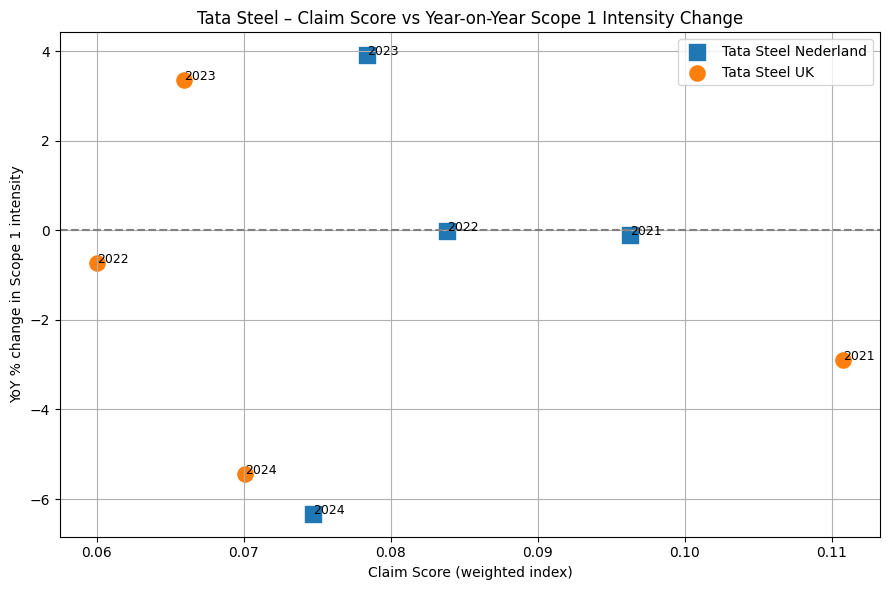

In [ ]:
# --- 3. Year-on-year % change in Scope 1 intensity (per company) ---
tata_merge = tata_merge.sort_values(["company", "year"]).copy()

tata_merge["yoy_scope1_intensity_pct"] = (
    tata_merge.groupby("company")["scope1_intensity"]
              .pct_change() * 100
)

print(tata_merge[["company", "year", "scope1_intensity",
                  "yoy_scope1_intensity_pct", "claim_score_mean"]])

# --- 4. Plot: Big Words vs YoY % change in Scope 1 intensity ---
import matplotlib.pyplot as plt

df_plot = tata_merge.dropna(subset=["yoy_scope1_intensity_pct", "claim_score_mean"])

plt.figure(figsize=(9, 6))

for company, marker in [
    ("Tata Steel Nederland", "s"),
    ("Tata Steel UK", "o"),
]:
    sub = df_plot[df_plot["company"] == company]
    if sub.empty:
        continue
    plt.scatter(
        sub["claim_score_mean"],
        sub["yoy_scope1_intensity_pct"],
        s=120,
        marker=marker,
        label=company,
    )
    # label points with year
    for _, row in sub.iterrows():
        plt.annotate(
            int(row["year"]),
            (row["claim_score_mean"], row["yoy_scope1_intensity_pct"]),
            fontsize=9,
        )

plt.axhline(0, color="gray", linestyle="--")  # 0 = no change
plt.xlabel("Claim Score (weighted index)")
plt.ylabel("YoY % change in Scope 1 intensity")
plt.title("Tata Steel – Claim Score vs Year-on-Year Scope 1 Intensity Change")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


| Situation                      | Communication behaviour | Interpretation                                                 |
| ------------------------------ | ----------------------- | -------------------------------------------------------------- |
| Emissions ↑ (bad performance)  | Claims ↑ 📣             | **High greenwashing risk**                                     |
| Emissions ↓ (good performance) | Claims ↓ 🤫             | **Underclaiming** (or messaging driven by PR, not performance) |


This is opposite of what genuine decarbonisation transparency looks like.

A real climate leader would:

communicate more when performance improves

communicate honestly or cautiously when it worsens

In [ ]:
# Keep only years where both metrics exist
df_summary = tata_merge.dropna(subset=["claim_score_mean", "yoy_scope1_intensity_pct"]).copy()

# Group means per country
group_stats = (
    df_summary
    .groupby("country")[["claim_score_mean", "yoy_scope1_intensity_pct"]]
    .mean()
    .rename(columns={
        "claim_score_mean": "avg_claim_score",
        "yoy_scope1_intensity_pct": "avg_yoy_intensity_pct"
    })
)

# Combined Tata average
combined_stats = pd.DataFrame({
    "avg_claim_score": [df_summary["claim_score_mean"].mean()],
    "avg_yoy_intensity_pct": [df_summary["yoy_scope1_intensity_pct"].mean()]
}, index=["Tata Combined"])

# Final table
final_stats = pd.concat([group_stats, combined_stats])
print(final_stats)


               avg_claim_score  avg_yoy_intensity_pct
NL                    0.083300              -0.631416
UK                    0.076694              -1.429426
Tata Combined         0.079997              -1.030421


| Pattern                                     | Interpretation                                                |
| ------------------------------------------- | ------------------------------------------------------------- |
| 🇳🇱 High claims + worsening CO₂            | **Greenwashing**                                              |
| 🇬🇧 Lower claims + improving CO₂           | **Underclaiming** (or genuine progress with modest messaging) |
| Combined: claims ↑ while sector still ↑ CO₂ | Corporate-level **misleading narrative**                      |


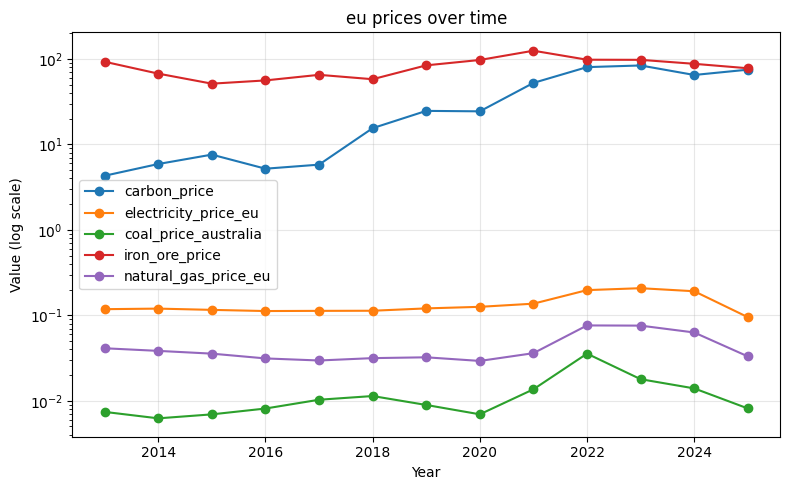

In [ ]:
price_to_plot = [
"carbon_price", 
"electricity_price_eu", 
"coal_price_australia", 
"iron_ore_price",
"natural_gas_price_eu"]


sub_co = df_countries[df_countries["country"] == 'Germany'].sort_values("year")

plt.figure(figsize=(8, 5))

for col in price_to_plot:
    if col in sub_co.columns:          # avoids errors if some are missing
        plt.plot(sub_co["year"], sub_co[col], marker="o", label=col)

plt.title(f"eu prices over time")
plt.xlabel("Year")
plt.ylabel("Value (log scale)")
plt.yscale("log")   
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

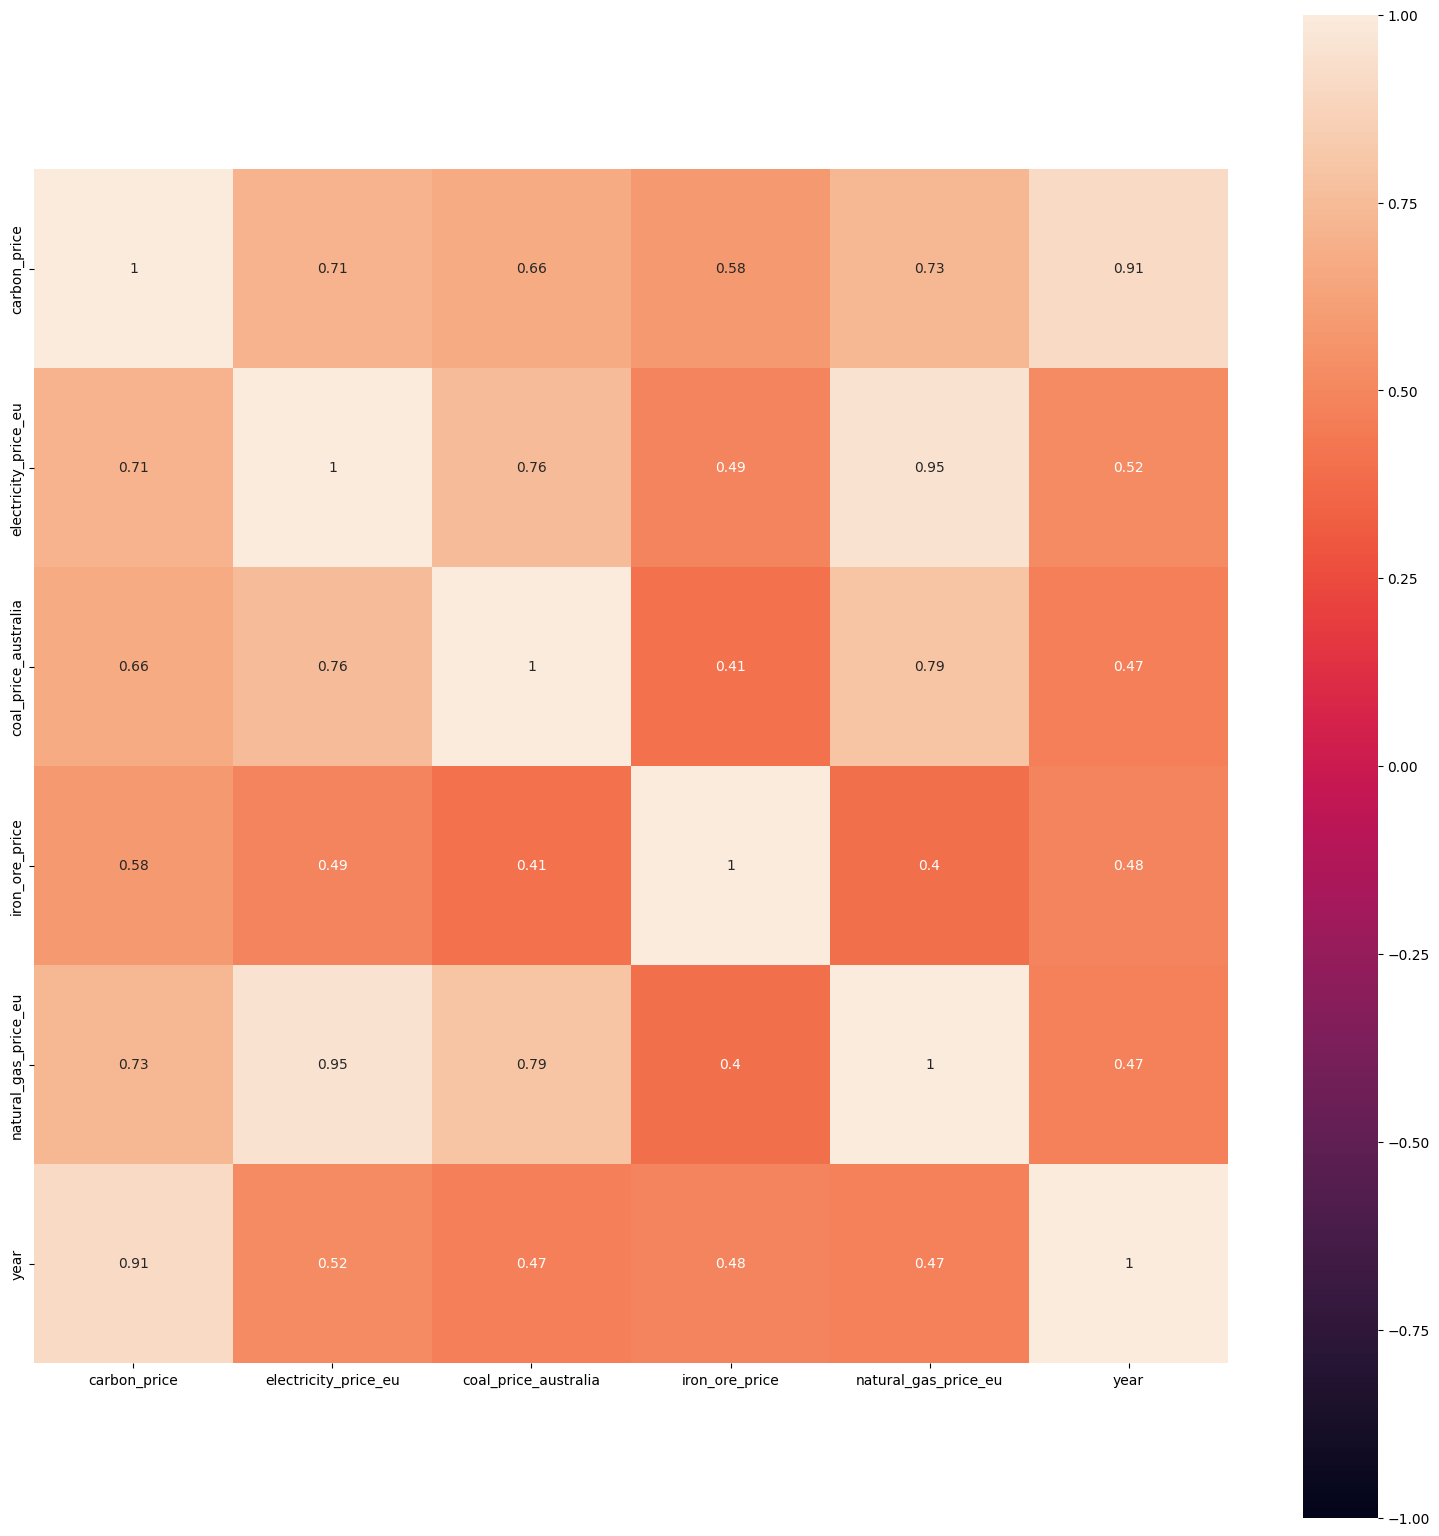

In [ ]:
prices_corr=df_countries[price_to_plot + ['year']]

#corr = vars_corr.corr()
#mask = np.tril(np.ones_like(corr, dtype=bool))

fig, axes = plt.subplots(1, 1, figsize=(16, 16))
#axes = axes.flatten()
sns.heatmap(prices_corr.corr(), annot=True, ax=axes, vmin=-1, vmax=1, square=True)
plt.tight_layout(pad = 3)